# Predviđanje Performansi NFL Igrača
## Korišćenjem Tehnika Mašinskog Učenja

**Autori:** Milan Jovkić, Uroš Petrašković  
**Predmet:** Analiza i Obrada Podataka  

---

### Pregled Projekta

Cilj ovog projekta je razvijanje prediktivnih modela za performanse NFL igrača koristeći istorijske podatke sa Pro Football Reference. Analiziramo četiri pozicije:

| Pozicija | Ciljna Varijabla | Izvor Podataka |
|----------|------------------|----------------|
| **QB** (Quarterback) | Passing Yards | pro-football-reference.com |
| **RB** (Running Back) | Rushing Yards | pro-football-reference.com |
| **WR** (Wide Receiver) | Receiving Yards | nflfastR play-by-play |
| **TE** (Tight End) | Receiving Yards | pro-football-reference.com |

### Metodologija
- **7 algoritama regresije**: Linear, Ridge, Lasso, ElasticNet, KNN, Random Forest, Gradient Boosting
- **Hronološki train/test split**: Poslednje 2 sezone = test set (bez curenja podataka)
- **SHAP analiza**: Za interpretabilnost modela
- **Multi-output regresija**: Simultano predviđanje više metrika

## 1. Uvoz Biblioteka

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print("Biblioteke uspešno učitane!")

Biblioteke uspešno učitane!


## 2. Učitavanje i Pregled Podataka

Učitavamo obrađene podatke za sve četiri pozicije:
- **QB**: Podaci o dodavanjima (passing)
- **RB**: Podaci o trčanju i primanju (rushing/receiving)
- **WR**: Play-by-play podaci o prijemu (receiving)
- **TE**: Podaci o prijemu i trčanju (receiving/rushing)

In [24]:
# Učitavanje podataka za sve pozicije
qb_data = pd.read_csv('data/processed/all_passing.csv')
rb_data = pd.read_csv('data/processed/all_rb_rushing_receiving.csv')
te_data = pd.read_csv('data/processed/all_te_receiving_rushing.csv')

# WR podaci - play-by-play iz više sezona (98 kolona po fajlu)
wr_files = sorted(glob.glob('data/raw/wr/**/wr_*.csv', recursive=True))
wr_dfs = []
for f in wr_files:
    df = pd.read_csv(f)
    # Izvlačimo sezonu iz game_id (npr. "2024_01_ARI_BUF" -> 2024)
    if 'game_id' in df.columns:
        df['Season'] = df['game_id'].str.split('_').str[0].astype(int)
    wr_dfs.append(df)
wr_data = pd.concat(wr_dfs, ignore_index=True)

# Agregacija WR podataka na nivo sezone (po igraču po sezoni)
# Koristimo iste kolone kao u glavnom pipeline-u (nfl_performance_prediction.py)
sum_cols = [
    'receiving_yards', 'air_yards', 'yac', 'first_downs',  # target + EDA kolone
    'targets', 'receptions', 'tds', 'explosive_plays',
    'red_zone_targets', 'end_zone_targets', 'third_down_targets',
    'fourth_down_targets', 'high_leverage_targets',
    'second_and_long_targets', 'third_and_medium_targets',
    'receptions_Q1', 'receptions_Q2', 'receptions_Q3', 'receptions_Q4',
    'targets_Q1', 'targets_Q2', 'targets_Q3', 'targets_Q4',
    'receptions_wp_<25', 'receptions_wp_25_45', 'receptions_wp_45_55',
    'receptions_wp_55_75', 'receptions_wp_>75',
    'targets_wp_<25', 'targets_wp_25_45', 'targets_wp_45_55',
    'targets_wp_55_75', 'targets_wp_>75',
]
mean_cols = [
    'catch_rate', 'success_rate', 'big_play_rate', 'td_rate',
    'epa', 'wpa', 'target_share', 'air_yard_share',
    'qb_comp_pct', 'qb_cpoe', 'qb_air_yards', 'qb_completions', 'qb_attempts',
    'adot', 'avg_depth', 'avg_score_diff', 'avg_quarter', 'leading_pct',
    'wp_var', 'target_share_std', 'reception_std',
    'avg_start_yardline', 'avg_target_depth_vs_qb',
    'team_pass_attempts', 'team_air_yards', 'team_epa',
    'def_targets_dev', 'def_receptions_dev', 'def_yards_dev',
    'def_tds_dev', 'def_epa_dev',
    'temp_f', 'humidity_pct', 'wind_mph',
    'is_dome', 'is_rain', 'is_clear', 'surface',
    'pregame_spread', 'pregame_total',
]
agg_dict = {}
for col in sum_cols:
    if col in wr_data.columns:
        agg_dict[col] = 'sum'
for col in mean_cols:
    if col in wr_data.columns:
        agg_dict[col] = 'mean'

wr_season = wr_data.groupby(['receiver_player_name', 'Season']).agg(agg_dict).reset_index()
games = wr_data.groupby(['receiver_player_name', 'Season']).size().reset_index(name='games')
wr_season = wr_season.merge(games, on=['receiver_player_name', 'Season'])
# Derived per-game stats (non-leaky)
wr_season['receptions_per_game'] = wr_season['receptions'] / wr_season['games']
wr_season['targets_per_game'] = wr_season['targets'] / wr_season['games']
wr_season['tds_per_game'] = wr_season['tds'] / wr_season['games']

print("=" * 65)
print("PREGLED UČITANIH PODATAKA")
print("=" * 65)

datasets = {
    'QB (Quarterbacks)': qb_data,
    'RB (Running Backs)': rb_data,
    'WR (Wide Receivers)': wr_season,
    'TE (Tight Ends)': te_data
}

for name, df in datasets.items():
    print(f"\n{'─' * 50}")
    print(f"  {name}")
    print(f"{'─' * 50}")
    print(f"  Redova: {len(df):,}  |  Kolona: {df.shape[1]}")
    if 'Player' in df.columns:
        print(f"  Igrača: {df['Player'].nunique()}")
    elif 'receiver_player_name' in df.columns:
        print(f"  Igrača: {df['receiver_player_name'].nunique()}")
    if 'Season' in df.columns:
        print(f"  Sezone: {int(df['Season'].min())} - {int(df['Season'].max())}")
    elif 'season' in df.columns:
        print(f"  Sezone: {int(df['season'].min())} - {int(df['season'].max())}")

print(f"\n{'=' * 65}")

PREGLED UČITANIH PODATAKA

──────────────────────────────────────────────────
  QB (Quarterbacks)
──────────────────────────────────────────────────
  Redova: 247  |  Kolona: 35
  Igrača: 33
  Sezone: 2005 - 2025

──────────────────────────────────────────────────
  RB (Running Backs)
──────────────────────────────────────────────────
  Redova: 91  |  Kolona: 37
  Igrača: 17
  Sezone: 2016 - 2025

──────────────────────────────────────────────────
  WR (Wide Receivers)
──────────────────────────────────────────────────
  Redova: 5,318  |  Kolona: 79
  Igrača: 1617
  Sezone: 2015 - 2025

──────────────────────────────────────────────────
  TE (Tight Ends)
──────────────────────────────────────────────────
  Redova: 194  |  Kolona: 37
  Igrača: 27
  Sezone: 2013 - 2025



In [25]:
# Prikaz prvih redova za svaku poziciju
print("QB - Prvih 5 redova:")
display(qb_data[['Season', 'Player', 'Team', 'Age', 'G', 'GS', 'Cmp', 'Att', 'Yds', 'TD', 'Int', 'Rate']].head())

print("\nRB - Prvih 5 redova:")
display(rb_data[['Season', 'Player', 'Team', 'Age', 'G', 'Att', 'Yds', 'TD', 'Rec', 'Yds.1']].head())

print("\nWR - Prvih 5 redova (agregirano na nivo sezone, 73+ kolone):")
wr_display_cols = ['receiver_player_name', 'Season', 'games', 'targets', 'receptions',
                   'receiving_yards', 'tds', 'catch_rate', 'adot', 'epa', 'target_share']
display(wr_season[wr_display_cols].sort_values('receiving_yards', ascending=False).head())

print("\nTE - Prvih 5 redova:")
display(te_data[['Season', 'Player', 'Team', 'Age', 'G', 'Tgt', 'Rec', 'Yds', 'TD']].head())

QB - Prvih 5 redova:


,Season,Player,Team,Age,G,GS,Cmp,Att,Yds,TD,Int,Rate
0,2005,Aaron Rodgers,GNB,22,3,0,9,16,65,0,1,39.8
1,2006,Aaron Rodgers,GNB,23,2,0,6,15,46,0,0,48.2
2,2007,Aaron Rodgers,GNB,24,2,0,20,28,218,1,0,106.0
3,2008,Aaron Rodgers,GNB,25,16,16,341,536,4038,28,13,93.8
4,2009,Aaron Rodgers,GNB,26,16,16,350,541,4434,30,7,103.2



RB - Prvih 5 redova:


,Season,Player,Team,Age,G,Att,Yds,TD,Rec,Yds.1
0,2017,Alvin Kamara,NOR,22,16,120,728,8,81,826
1,2018,Alvin Kamara,NOR,23,15,194,883,14,81,709
2,2019,Alvin Kamara,NOR,24,14,171,797,5,81,533
3,2020,Alvin Kamara,NOR,25,15,187,932,16,83,756
4,2021,Alvin Kamara,NOR,26,13,240,898,4,47,439



WR - Prvih 5 redova (agregirano na nivo sezone, 73+ kolone):


,receiver_player_name,Season,games,targets,receptions,receiving_yards,tds,catch_rate,adot,epa,target_share
2578,J.Jones,2015,34,317.0,193.0,2842.0,16.0,0.567047,12.980193,3.396506,0.255627
912,C.Kupp,2021,21,233.0,178.0,2425.0,22.0,0.769057,8.633856,6.768008,0.310655
4841,T.Hill,2023,32,218.0,157.0,2152.0,16.0,0.771855,8.009659,3.150114,0.222867
2709,J.Nelson,2016,32,238.0,137.0,1896.0,21.0,0.563614,15.007280,2.901075,0.194241
2557,J.Jefferson,2022,18,194.0,135.0,1856.0,8.0,0.676315,9.991272,4.219936,0.305688



TE - Prvih 5 redova:


,Season,Player,Team,Age,G,Tgt,Rec,Yds,TD
0,2024,Brock Bowers,LVR,22,17,153,112,1194,5
1,2025,Brock Bowers,LVR,23,12,86,64,680,7
2,2015,C.J. Uzomah,CIN,22,5,1,1,4,0
3,2016,C.J. Uzomah,CIN,23,10,38,25,234,1
4,2017,C.J. Uzomah,CIN,24,14,15,10,92,1


## 3. Čišćenje Podataka i Nedostajuće Vrednosti

Pre modeliranja, proveravamo kvalitet podataka - nedostajuće vrednosti, tipove podataka i osnovnu strukturu.

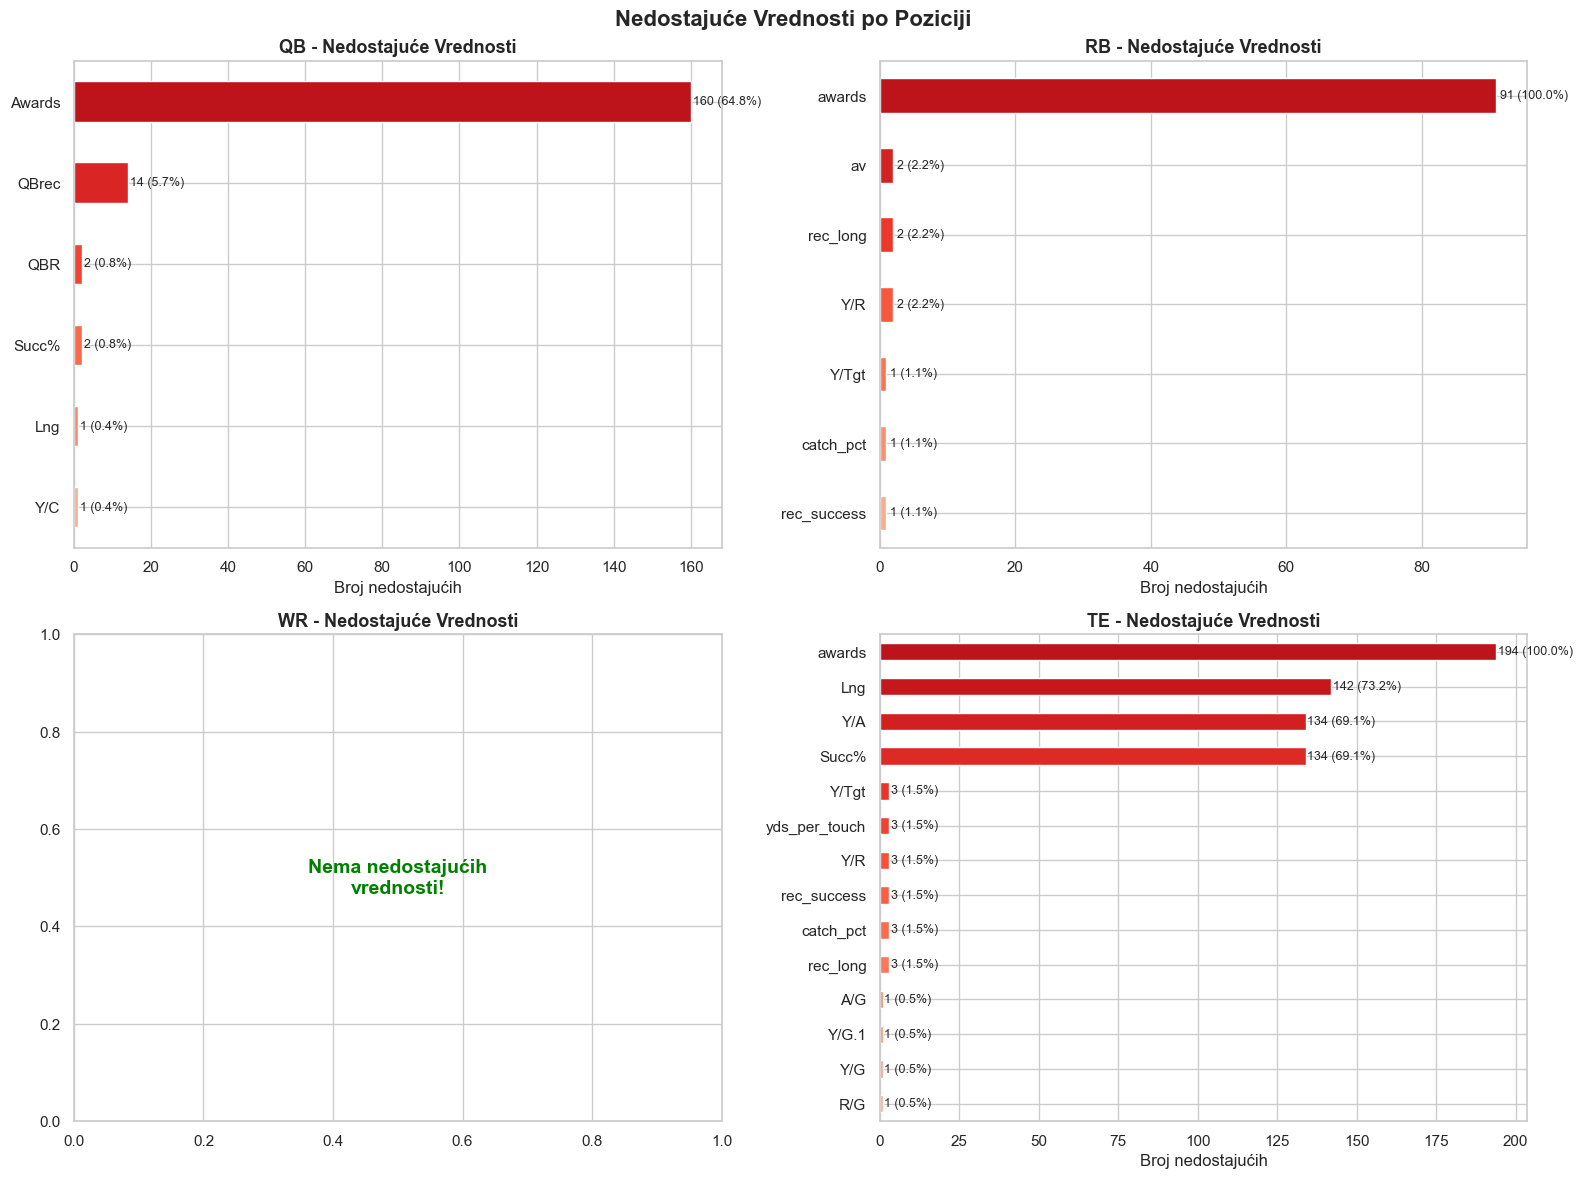

In [ ]:
# Analiza nedostajućih vrednosti za svaku poziciju
# NAPOMENA: 'Awards' kolona se isključuje iz analize jer većina igrača nema nagrade - to nije "nedostajuća" vrednost
award_cols = ['Awards', 'awards']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Nedostajuće Vrednosti po Poziciji (bez Awards kolone)', fontsize=16, fontweight='bold')

position_data = {
    'QB': qb_data, 'RB': rb_data,
    'WR': wr_season, 'TE': te_data
}

for idx, (pos, df) in enumerate(position_data.items()):
    ax = axes[idx // 2][idx % 2]
    missing = df.isnull().sum()
    # Isključujemo Awards kolonu - nije pravi nedostajući podatak
    missing = missing.drop(labels=[c for c in award_cols if c in missing.index], errors='ignore')
    missing = missing[missing > 0].sort_values(ascending=True)
    if len(missing) > 0:
        colors = plt.cm.Reds(np.linspace(0.3, 0.8, len(missing)))
        missing.plot(kind='barh', ax=ax, color=colors)
        ax.set_title(f'{pos} - Nedostajuće Vrednosti', fontsize=13, fontweight='bold')
        ax.set_xlabel('Broj nedostajućih')
        for i, v in enumerate(missing):
            ax.text(v + 0.5, i, f'{v} ({v/len(df)*100:.1f}%)', va='center', fontsize=9)
    else:
        ax.text(0.5, 0.5, 'Nema nedostajućih\nvrednosti!', transform=ax.transAxes,
                ha='center', va='center', fontsize=14, color='green', fontweight='bold')
        ax.set_title(f'{pos} - Nedostajuće Vrednosti', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Popunjavamo Awards kolone sa 'None' umesto NaN
for pos, df in position_data.items():
    for col in award_cols:
        if col in df.columns:
            df[col] = df[col].fillna('None')
            
print("✅ Awards kolone popunjene sa 'None' - nisu pravi nedostajući podaci jer većina igrača nema nagrade.")

In [27]:
# Tipovi podataka i osnovne statistike
print("=" * 65)
print("TIPOVI PODATAKA PO POZICIJI")
print("=" * 65)
for pos, df in position_data.items():
    numeric = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical = df.select_dtypes(include=['object']).columns.tolist()
    print(f"\n{pos}: {len(numeric)} numeričkih | {len(categorical)} kategorijskih kolona")
    print(f"  Numeričke: {', '.join(numeric[:8])}{'...' if len(numeric) > 8 else ''}")
    print(f"  Kategorijske: {', '.join(categorical)}")

TIPOVI PODATAKA PO POZICIJI

QB: 29 numeričkih | 6 kategorijskih kolona
  Numeričke: Season, Age, G, GS, Cmp, Att, Cmp%, Yds...
  Kategorijske: Team, Pos, QBrec, Awards, Player, PlayerID

RB: 32 numeričkih | 5 kategorijskih kolona
  Numeričke: Season, Age, G, GS, Att, Yds, TD, 1D...
  Kategorijske: Team, Lg, Pos, Player, PlayerID

WR: 78 numeričkih | 1 kategorijskih kolona
  Numeričke: Season, receiving_yards, air_yards, yac, first_downs, targets, receptions, tds...
  Kategorijske: receiver_player_name

TE: 32 numeričkih | 5 kategorijskih kolona
  Numeričke: Season, Age, G, GS, Tgt, Rec, Yds, Y/R...
  Kategorijske: Team, Lg, Pos, Player, PlayerID


## 4. Eksplorativna Analiza Podataka (EDA) - Sumarne Statistike

Pregled distribucija ciljnih varijabli (yards) po svakoj poziciji i osnovne deskriptivne statistike.

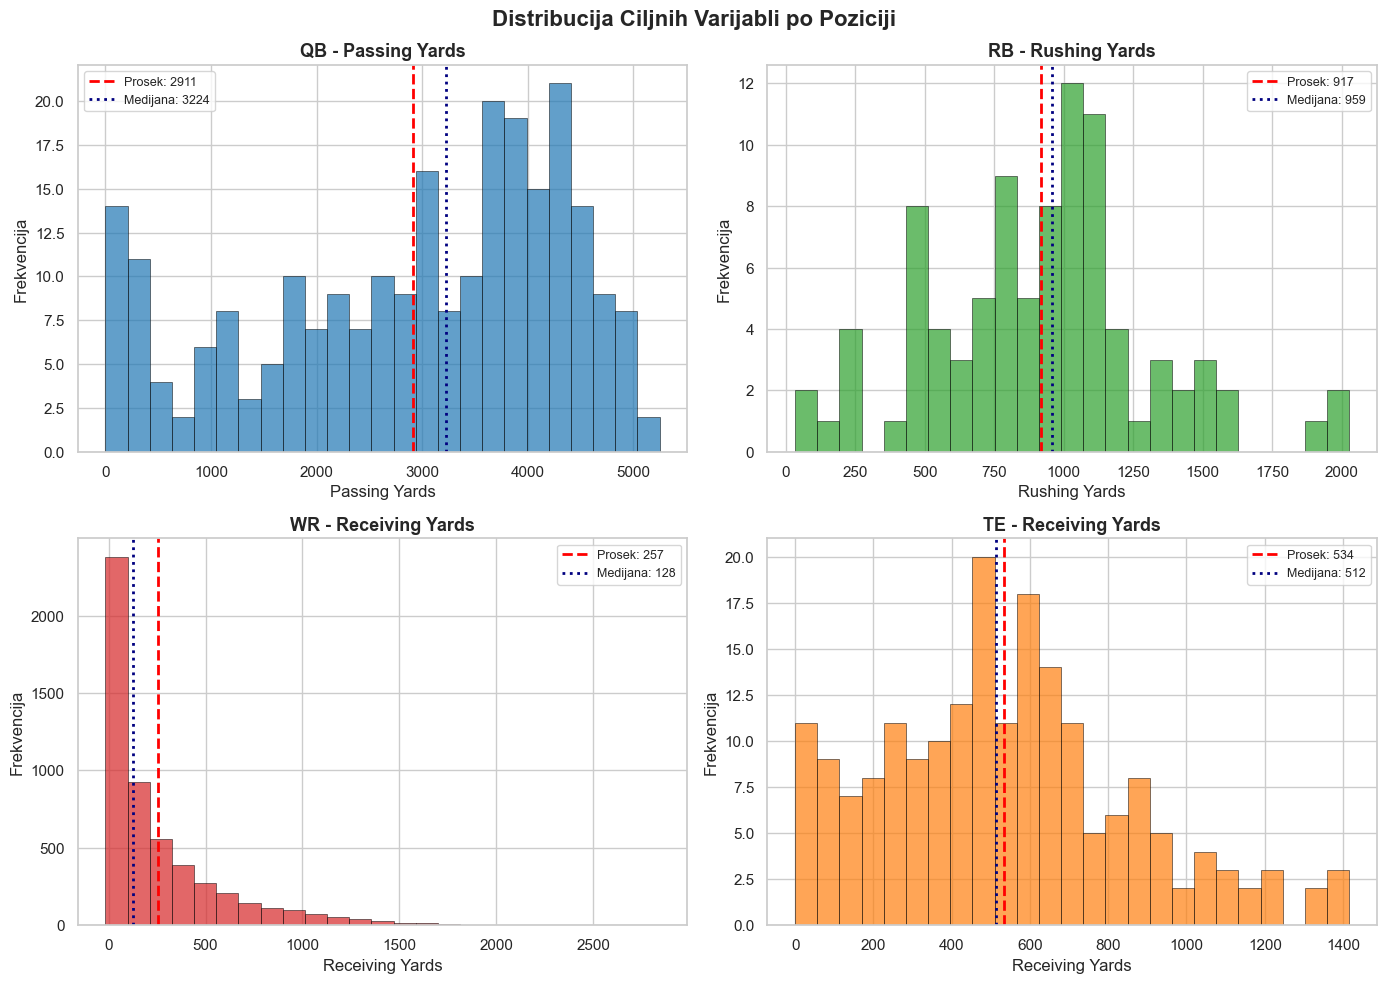

In [28]:
# Distribucija ciljnih varijabli
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribucija Ciljnih Varijabli po Poziciji', fontsize=16, fontweight='bold')

targets = [
    ('QB', qb_data, 'Yds', 'Passing Yards'),
    ('RB', rb_data, 'Yds', 'Rushing Yards'),
    ('WR', wr_season, 'receiving_yards', 'Receiving Yards'),
    ('TE', te_data, 'Yds', 'Receiving Yards')
]

colors = ['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e']

for idx, (pos, df, col, label) in enumerate(targets):
    ax = axes[idx // 2][idx % 2]
    data = df[col].dropna()
    ax.hist(data, bins=25, color=colors[idx], alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Prosek: {data.mean():.0f}')
    ax.axvline(data.median(), color='navy', linestyle=':', linewidth=2, label=f'Medijana: {data.median():.0f}')
    ax.set_title(f'{pos} - {label}', fontsize=13, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frekvencija')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [29]:
# Deskriptivne statistike za ciljne varijable
summary_stats = []
for pos, df, col, label in targets:
    data = df[col].dropna()
    summary_stats.append({
        'Pozicija': pos,
        'Ciljna varijabla': label,
        'Broj uzoraka': len(data),
        'Prosek': round(data.mean(), 1),
        'Std. Dev.': round(data.std(), 1),
        'Min': round(data.min(), 1),
        '25%': round(data.quantile(0.25), 1),
        'Medijana': round(data.median(), 1),
        '75%': round(data.quantile(0.75), 1),
        'Max': round(data.max(), 1)
    })

stats_df = pd.DataFrame(summary_stats)
print("Sumarne Statistike Ciljnih Varijabli:")
display(stats_df.set_index('Pozicija'))

Sumarne Statistike Ciljnih Varijabli:


,Ciljna varijabla,Broj uzoraka,Prosek,Std. Dev.,Min,25%,Medijana,75%,Max
Pozicija,,,,,,,,,
QB,Passing Yards,247,2911.1,1444.1,0.0,1863.0,3224.0,4088.5,5250.0
RB,Rushing Yards,91,916.9,404.0,34.0,660.0,959.0,1114.5,2027.0
WR,Receiving Yards,5318,257.0,324.4,-16.0,31.0,128.0,362.8,2842.0
TE,Receiving Yards,194,534.2,319.3,0.0,294.2,512.0,716.0,1416.0


## 5. Stupčasti Grafikon - Prosečan Učinak po Igraču

Poređenje prosečnog broja jardi po igraču za svaku poziciju. Prikazujemo top 10 igrača po prosečnim jardima po sezoni.

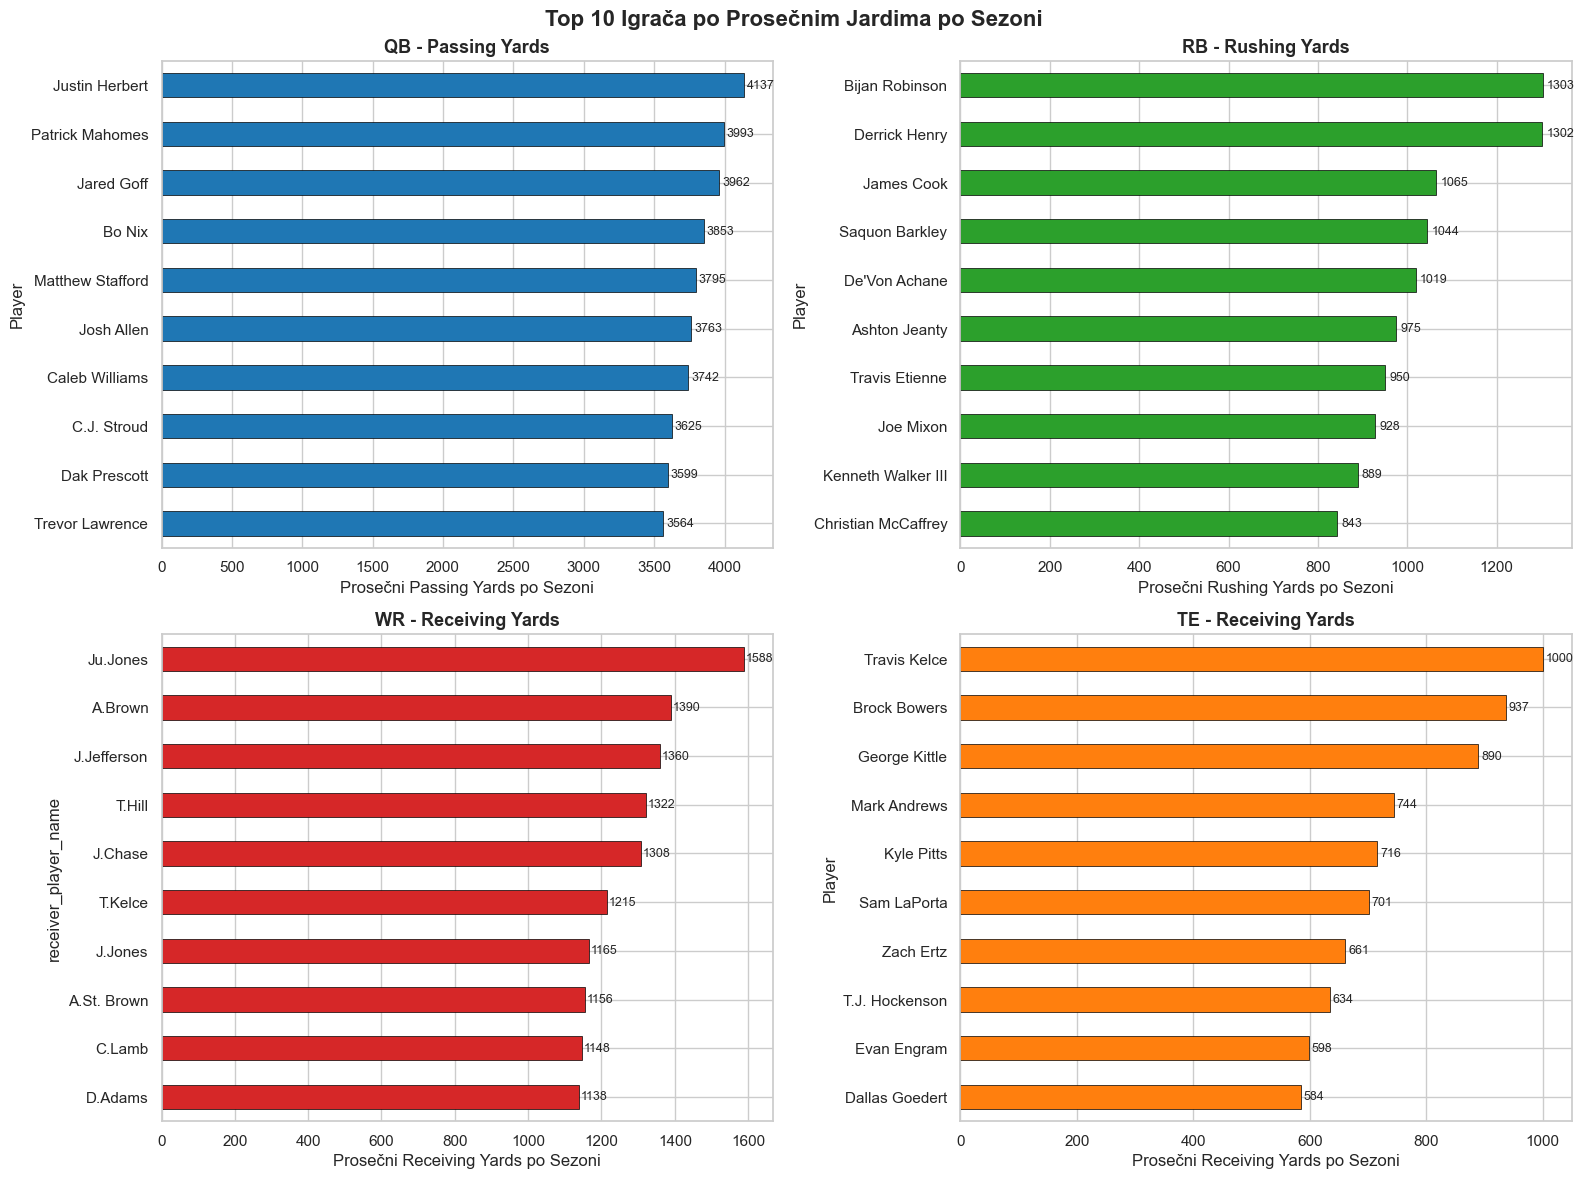

In [30]:
# Top 10 igrača po prosečnim jardima po sezoni - za svaku poziciju
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Top 10 Igrača po Prosečnim Jardima po Sezoni', fontsize=16, fontweight='bold')

# QB - Passing Yards
ax = axes[0][0]
qb_avg = qb_data.groupby('Player')['Yds'].mean().sort_values(ascending=True).tail(10)
qb_avg.plot(kind='barh', ax=ax, color='#1f77b4', edgecolor='black', linewidth=0.5)
ax.set_title('QB - Passing Yards', fontsize=13, fontweight='bold')
ax.set_xlabel('Prosečni Passing Yards po Sezoni')
for i, v in enumerate(qb_avg):
    ax.text(v + 20, i, f'{v:.0f}', va='center', fontsize=9)

# RB - Rushing Yards
ax = axes[0][1]
rb_avg = rb_data.groupby('Player')['Yds'].mean().sort_values(ascending=True).tail(10)
rb_avg.plot(kind='barh', ax=ax, color='#2ca02c', edgecolor='black', linewidth=0.5)
ax.set_title('RB - Rushing Yards', fontsize=13, fontweight='bold')
ax.set_xlabel('Prosečni Rushing Yards po Sezoni')
for i, v in enumerate(rb_avg):
    ax.text(v + 10, i, f'{v:.0f}', va='center', fontsize=9)

# WR - Receiving Yards
ax = axes[1][0]
wr_avg = wr_season.groupby('receiver_player_name')['receiving_yards'].mean().sort_values(ascending=True).tail(10)
wr_avg.plot(kind='barh', ax=ax, color='#d62728', edgecolor='black', linewidth=0.5)
ax.set_title('WR - Receiving Yards', fontsize=13, fontweight='bold')
ax.set_xlabel('Prosečni Receiving Yards po Sezoni')
for i, v in enumerate(wr_avg):
    ax.text(v + 5, i, f'{v:.0f}', va='center', fontsize=9)

# TE - Receiving Yards
ax = axes[1][1]
te_avg = te_data.groupby('Player')['Yds'].mean().sort_values(ascending=True).tail(10)
te_avg.plot(kind='barh', ax=ax, color='#ff7f0e', edgecolor='black', linewidth=0.5)
ax.set_title('TE - Receiving Yards', fontsize=13, fontweight='bold')
ax.set_xlabel('Prosečni Receiving Yards po Sezoni')
for i, v in enumerate(te_avg):
    ax.text(v + 5, i, f'{v:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Linijski Grafikoni - Trendovi Kroz Sezone

Praćenje razvoja performansi igrača kroz godine. Za svaku poziciju prikazujemo karijerne trajektorije top igrača.

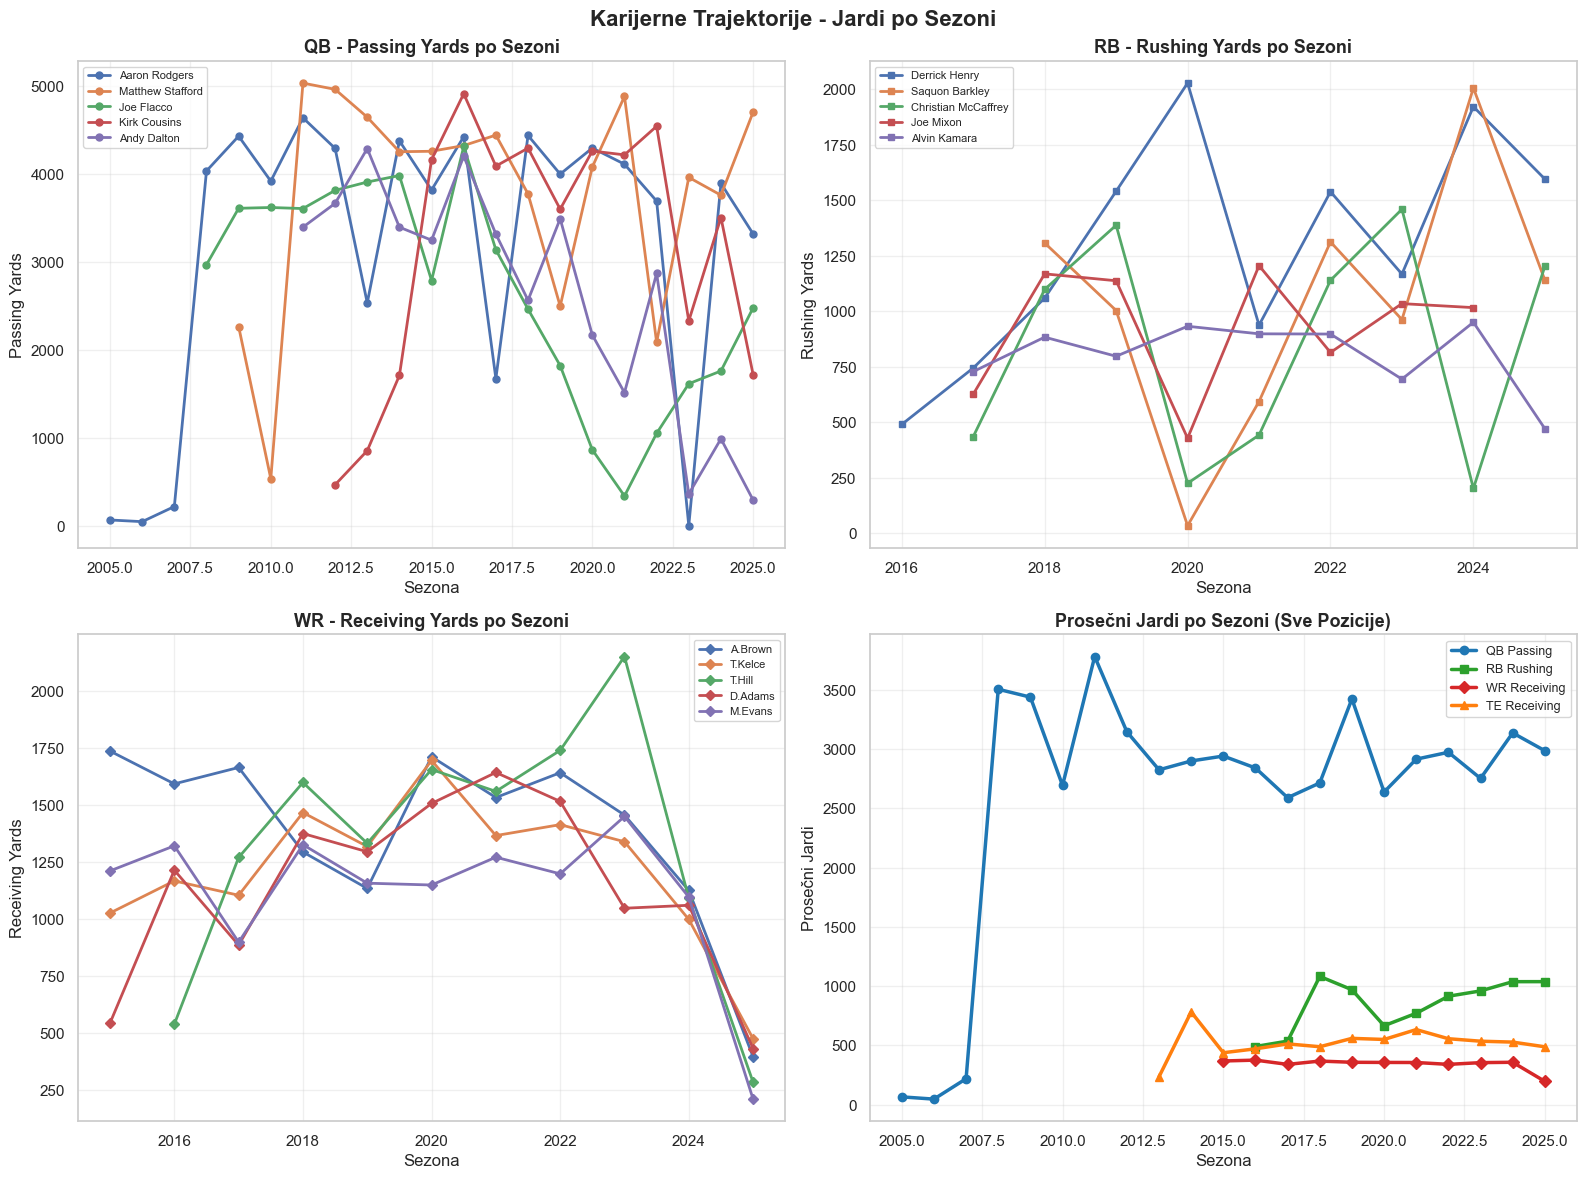

In [31]:
# Karijerne trajektorije - QB Passing Yards
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Karijerne Trajektorije - Jardi po Sezoni', fontsize=16, fontweight='bold')

# QB: top 5 igrača po ukupnim jardima
ax = axes[0][0]
top_qbs = qb_data.groupby('Player')['Yds'].sum().nlargest(5).index
for player in top_qbs:
    pdata = qb_data[qb_data['Player'] == player].sort_values('Season')
    ax.plot(pdata['Season'], pdata['Yds'], marker='o', linewidth=2, markersize=5, label=player)
ax.set_title('QB - Passing Yards po Sezoni', fontsize=13, fontweight='bold')
ax.set_xlabel('Sezona')
ax.set_ylabel('Passing Yards')
ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.3)

# RB: top 5 igrača
ax = axes[0][1]
top_rbs = rb_data.groupby('Player')['Yds'].sum().nlargest(5).index
for player in top_rbs:
    pdata = rb_data[rb_data['Player'] == player].sort_values('Season')
    ax.plot(pdata['Season'], pdata['Yds'], marker='s', linewidth=2, markersize=5, label=player)
ax.set_title('RB - Rushing Yards po Sezoni', fontsize=13, fontweight='bold')
ax.set_xlabel('Sezona')
ax.set_ylabel('Rushing Yards')
ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.3)

# WR: top 5 igrača po ukupnim jardima (umesto TE u ovom panelu)
ax = axes[1][0]
# Filter WR sa >= 4 utakmica
wr_filtered = wr_season[wr_season['games'] >= 4]
top_wrs = wr_filtered.groupby('receiver_player_name')['receiving_yards'].sum().nlargest(5).index
for player in top_wrs:
    pdata = wr_filtered[wr_filtered['receiver_player_name'] == player].sort_values('Season')
    ax.plot(pdata['Season'], pdata['receiving_yards'], marker='D', linewidth=2, markersize=5, label=player)
ax.set_title('WR - Receiving Yards po Sezoni', fontsize=13, fontweight='bold')
ax.set_xlabel('Sezona')
ax.set_ylabel('Receiving Yards')
ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.3)

# Prosečni jardi po sezoni - sve pozicije
ax = axes[1][1]
qb_season_avg = qb_data.groupby('Season')['Yds'].mean()
rb_season_avg = rb_data.groupby('Season')['Yds'].mean()
wr_season_avg = wr_filtered.groupby('Season')['receiving_yards'].mean()
te_season_avg = te_data.groupby('Season')['Yds'].mean()

ax.plot(qb_season_avg.index, qb_season_avg.values, marker='o', linewidth=2.5, label='QB Passing', color='#1f77b4')
ax.plot(rb_season_avg.index, rb_season_avg.values, marker='s', linewidth=2.5, label='RB Rushing', color='#2ca02c')
ax.plot(wr_season_avg.index, wr_season_avg.values, marker='D', linewidth=2.5, label='WR Receiving', color='#d62728')
ax.plot(te_season_avg.index, te_season_avg.values, marker='^', linewidth=2.5, label='TE Receiving', color='#ff7f0e')
ax.set_title('Prosečni Jardi po Sezoni (Sve Pozicije)', fontsize=13, fontweight='bold')
ax.set_xlabel('Sezona')
ax.set_ylabel('Prosečni Jardi')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Scatter Plotovi - Korelacije Između Varijabli

Istraživanje odnosa između ključnih statistika. Scatter plotovi pokazuju koliko su jake veze između pokušaja, efikasnosti i ukupnih jardi.

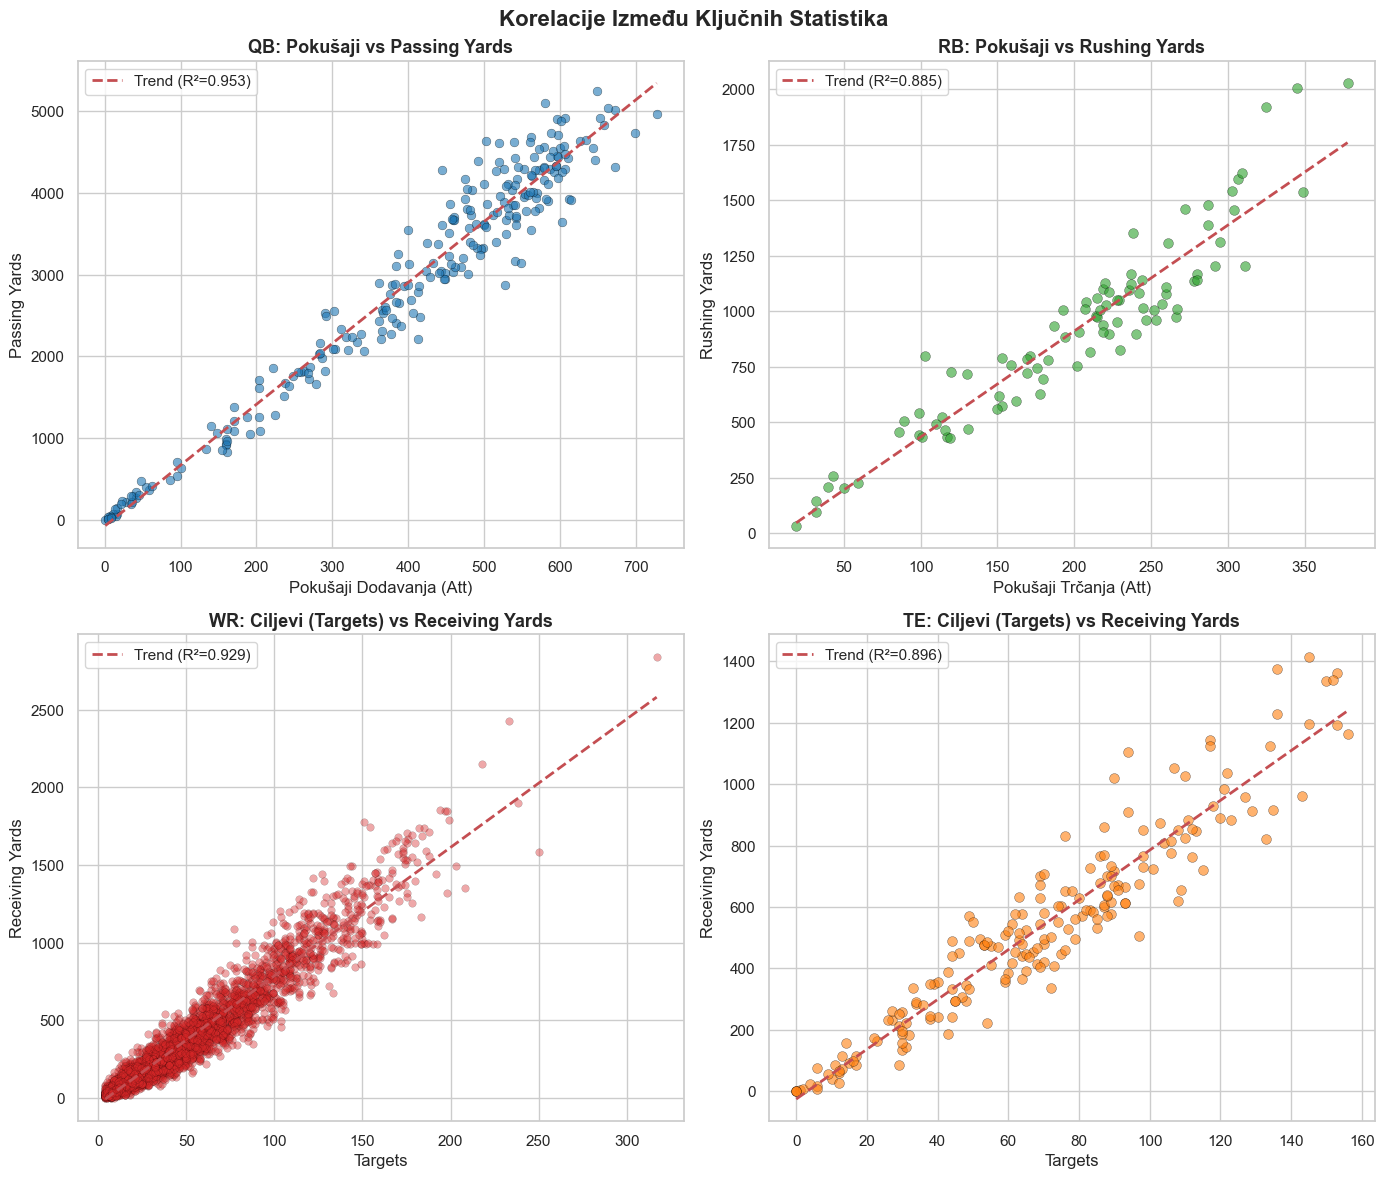

In [32]:
# Scatter plotovi - ključne korelacije
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Korelacije Između Ključnih Statistika', fontsize=16, fontweight='bold')

# QB: Attempts vs Passing Yards
ax = axes[0][0]
ax.scatter(qb_data['Att'], qb_data['Yds'], alpha=0.6, c='#1f77b4', edgecolors='black', linewidth=0.3, s=40)
z = np.polyfit(qb_data['Att'].dropna(), qb_data.loc[qb_data['Att'].notna(), 'Yds'], 1)
p = np.poly1d(z)
x_line = np.linspace(qb_data['Att'].min(), qb_data['Att'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Trend (R²={np.corrcoef(qb_data["Att"].dropna(), qb_data.loc[qb_data["Att"].notna(), "Yds"])[0,1]**2:.3f})')
ax.set_title('QB: Pokušaji vs Passing Yards', fontsize=13, fontweight='bold')
ax.set_xlabel('Pokušaji Dodavanja (Att)')
ax.set_ylabel('Passing Yards')
ax.legend()

# RB: Attempts vs Rushing Yards
ax = axes[0][1]
ax.scatter(rb_data['Att'], rb_data['Yds'], alpha=0.6, c='#2ca02c', edgecolors='black', linewidth=0.3, s=50)
z = np.polyfit(rb_data['Att'].dropna(), rb_data.loc[rb_data['Att'].notna(), 'Yds'], 1)
p = np.poly1d(z)
x_line = np.linspace(rb_data['Att'].min(), rb_data['Att'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Trend (R²={np.corrcoef(rb_data["Att"].dropna(), rb_data.loc[rb_data["Att"].notna(), "Yds"])[0,1]**2:.3f})')
ax.set_title('RB: Pokušaji vs Rushing Yards', fontsize=13, fontweight='bold')
ax.set_xlabel('Pokušaji Trčanja (Att)')
ax.set_ylabel('Rushing Yards')
ax.legend()

# WR: Targets vs Receiving Yards (sa 73+ feature-a)
ax = axes[1][0]
wr_plot = wr_season[wr_season['games'] >= 4].copy()
ax.scatter(wr_plot['targets'], wr_plot['receiving_yards'], alpha=0.4, c='#d62728', edgecolors='black', linewidth=0.2, s=30)
z = np.polyfit(wr_plot['targets'].dropna(), wr_plot.loc[wr_plot['targets'].notna(), 'receiving_yards'], 1)
p = np.poly1d(z)
x_line = np.linspace(wr_plot['targets'].min(), wr_plot['targets'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Trend (R²={np.corrcoef(wr_plot["targets"].dropna(), wr_plot.loc[wr_plot["targets"].notna(), "receiving_yards"])[0,1]**2:.3f})')
ax.set_title('WR: Ciljevi (Targets) vs Receiving Yards', fontsize=13, fontweight='bold')
ax.set_xlabel('Targets')
ax.set_ylabel('Receiving Yards')
ax.legend()

# TE: Targets vs Receiving Yards
ax = axes[1][1]
ax.scatter(te_data['Tgt'], te_data['Yds'], alpha=0.6, c='#ff7f0e', edgecolors='black', linewidth=0.3, s=50)
z = np.polyfit(te_data['Tgt'].dropna(), te_data.loc[te_data['Tgt'].notna(), 'Yds'], 1)
p = np.poly1d(z)
x_line = np.linspace(te_data['Tgt'].min(), te_data['Tgt'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Trend (R²={np.corrcoef(te_data["Tgt"].dropna(), te_data.loc[te_data["Tgt"].notna(), "Yds"])[0,1]**2:.3f})')
ax.set_title('TE: Ciljevi (Targets) vs Receiving Yards', fontsize=13, fontweight='bold')
ax.set_xlabel('Targets')
ax.set_ylabel('Receiving Yards')
ax.legend()

plt.tight_layout()
plt.show()

## 8. Korelacione Matrice (Heatmaps)

Vizualizacija korelacija između svih numeričkih varijabli za QB i RB pozicije. Ovo pomaže u identifikaciji ključnih prediktora.

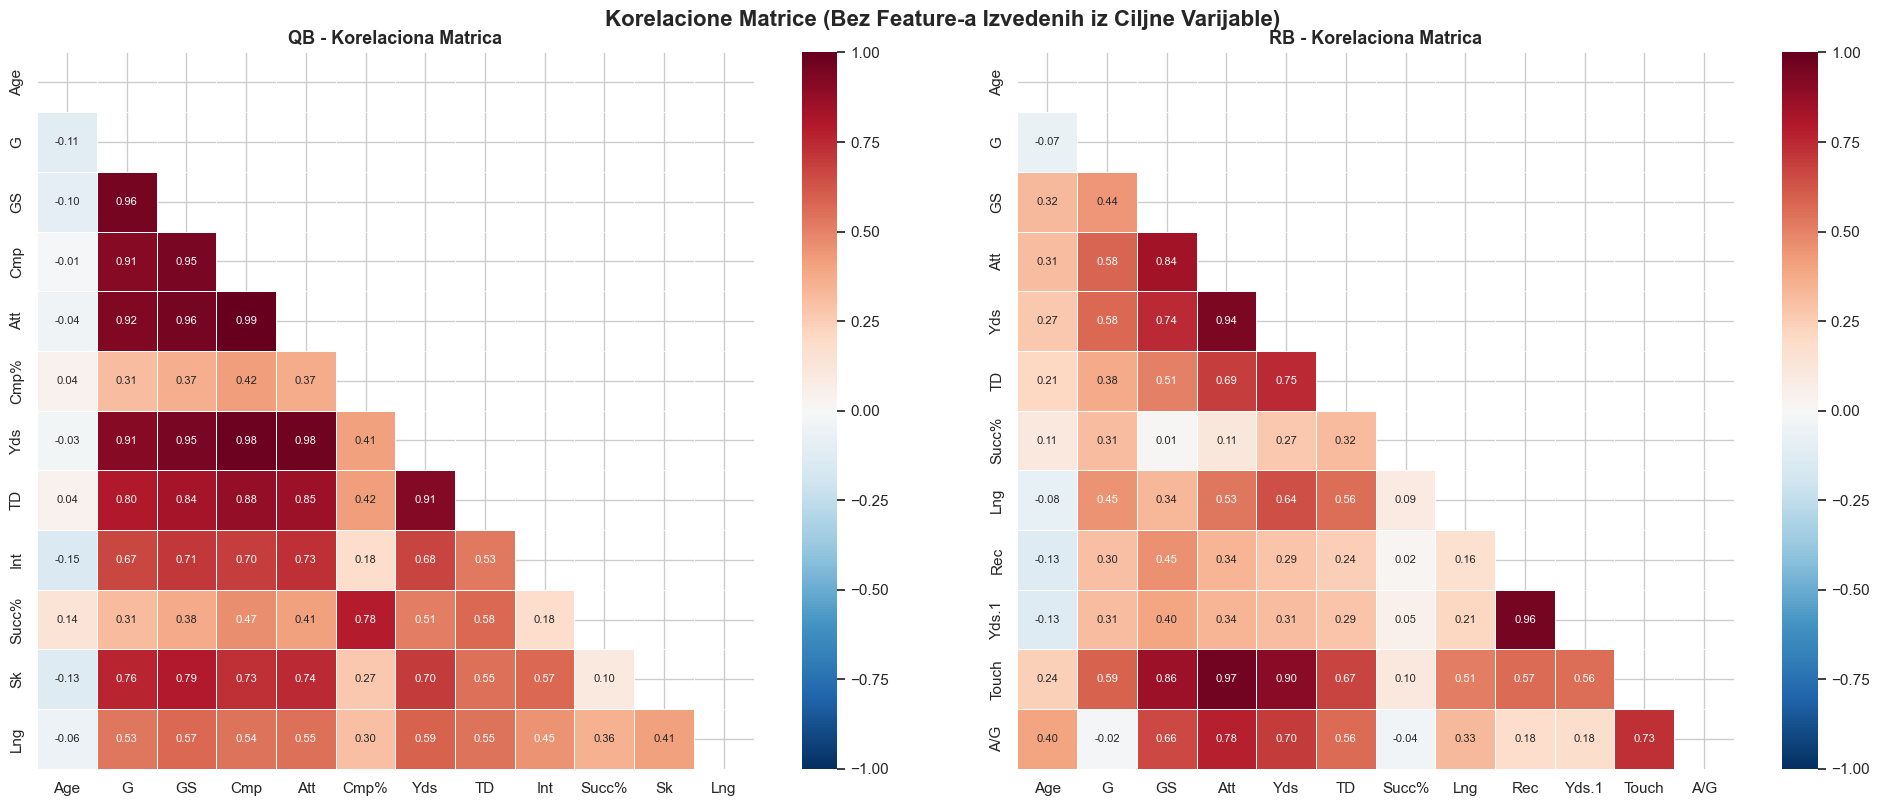

In [33]:
# Korelaciona matrica za QB i RB podatke (bez leaky feature-a)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Korelacione Matrice (Bez Feature-a Izvedenih iz Ciljne Varijable)', fontsize=16, fontweight='bold')

# QB korelacija - bez leaky feature-a (1D, Y/A, Y/G, Rate, QBR su uklonjeni)
qb_corr_cols = ['Age', 'G', 'GS', 'Cmp', 'Att', 'Cmp%', 'Yds', 'TD', 'Int', 'Succ%', 'Sk', 'Lng']
qb_corr = qb_data[qb_corr_cols].corr()
mask = np.triu(np.ones_like(qb_corr, dtype=bool))
sns.heatmap(qb_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[0], square=True, linewidths=0.5, annot_kws={'size': 8},
            vmin=-1, vmax=1)
axes[0].set_title('QB - Korelaciona Matrica', fontsize=13, fontweight='bold')

# RB korelacija - bez leaky feature-a (1D, Y/A, Y/G su uklonjeni)
rb_corr_cols = ['Age', 'G', 'GS', 'Att', 'Yds', 'TD', 'Succ%', 'Lng', 'Rec', 'Yds.1', 'Touch', 'A/G']
rb_corr = rb_data[rb_corr_cols].corr()
mask = np.triu(np.ones_like(rb_corr, dtype=bool))
sns.heatmap(rb_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[1], square=True, linewidths=0.5, annot_kws={'size': 8},
            vmin=-1, vmax=1)
axes[1].set_title('RB - Korelaciona Matrica', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Proporcionalni Prikaz - Struktura Dataset-a

Kružni grafikoni prikazuju raspodelu podataka po pozicijama i timovima.

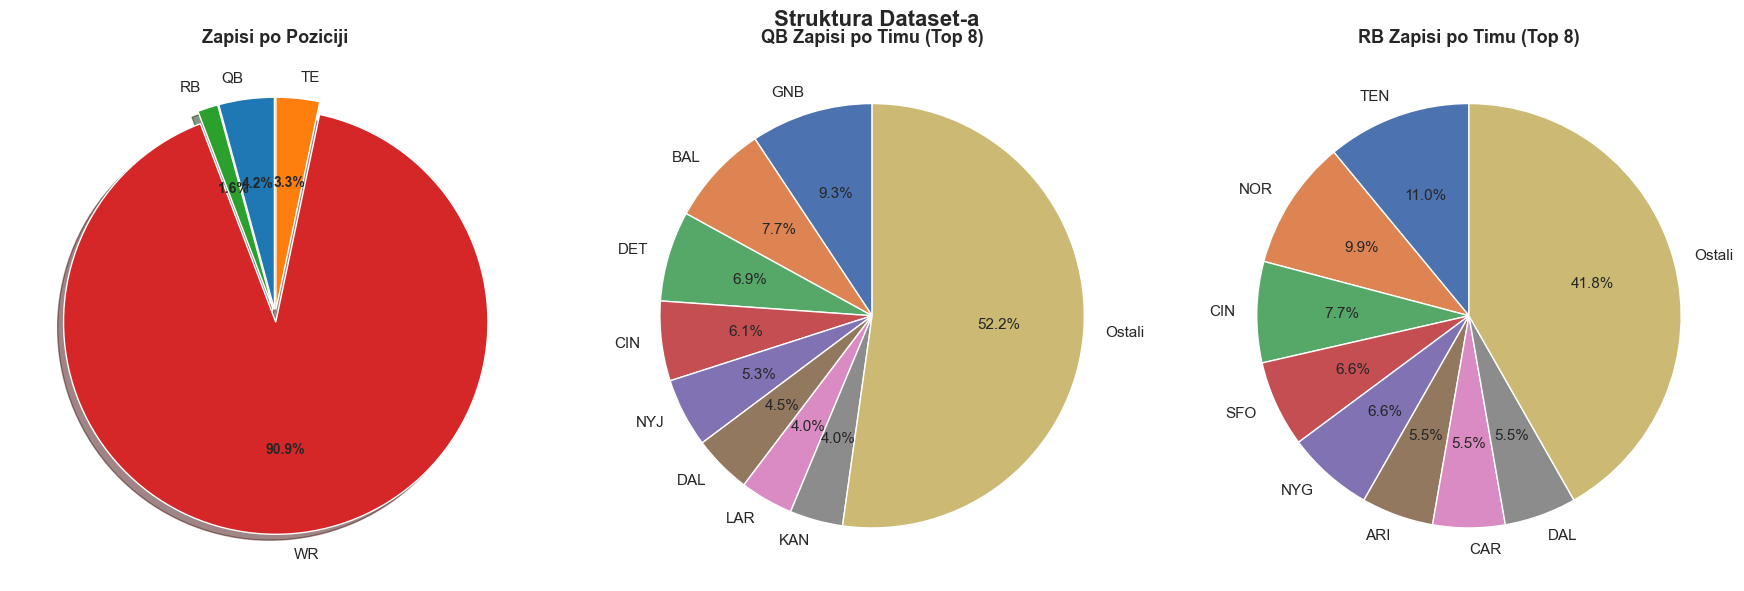

In [34]:
# Raspodela podataka po pozicijama i timovima
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Struktura Dataset-a', fontsize=16, fontweight='bold')

# Pie chart: Broj zapisa po poziciji
ax = axes[0]
sizes = [len(qb_data), len(rb_data), len(wr_season), len(te_data)]
labels = ['QB', 'RB', 'WR', 'TE']
colors_pie = ['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e']
explode = (0.03, 0.03, 0.03, 0.03)
wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors_pie,
                                    autopct='%1.1f%%', startangle=90,
                                    explode=explode, shadow=True)
for t in autotexts:
    t.set_fontsize(10)
    t.set_fontweight('bold')
ax.set_title('Zapisi po Poziciji', fontsize=13, fontweight='bold')

# Pie chart: QB timovi
ax = axes[1]
qb_teams = qb_data['Team'].value_counts().head(8)
other = len(qb_data) - qb_teams.sum()
if other > 0:
    qb_teams['Ostali'] = other
ax.pie(qb_teams, labels=qb_teams.index, autopct='%1.1f%%', startangle=90)
ax.set_title('QB Zapisi po Timu (Top 8)', fontsize=13, fontweight='bold')

# Pie chart: RB timovi
ax = axes[2]
rb_teams = rb_data['Team'].value_counts().head(8)
other = len(rb_data) - rb_teams.sum()
if other > 0:
    rb_teams['Ostali'] = other
ax.pie(rb_teams, labels=rb_teams.index, autopct='%1.1f%%', startangle=90)
ax.set_title('RB Zapisi po Timu (Top 8)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 10. Detaljnija Analiza QB Statistika

Dublja analiza quarterback performansi: efikasnost dodavanja, odnos TD/INT, uticaj starosti, i razne scatter korelacije.

In [ ]:
# ==========================================
# QB: 6 grafika u jednom panelu
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('QB Detaljna Analiza', fontsize=18, fontweight='bold')

# 1. Completion % vs Passer Rating
ax = axes[0][0]
valid = qb_data.dropna(subset=['Cmp%', 'Rate'])
scatter = ax.scatter(valid['Cmp%'], valid['Rate'], c=valid['Yds'], cmap='coolwarm',
                     alpha=0.7, edgecolors='black', linewidth=0.3, s=50)
plt.colorbar(scatter, ax=ax, label='Passing Yards')
ax.set_title('Completion % vs Passer Rating', fontsize=12, fontweight='bold')
ax.set_xlabel('Completion %')
ax.set_ylabel('Passer Rating')
# Trend line
z = np.polyfit(valid['Cmp%'], valid['Rate'], 1)
p = np.poly1d(z)
x_line = np.linspace(valid['Cmp%'].min(), valid['Cmp%'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=2, alpha=0.7)

# 2. TD vs INT scatter (bubble = Yds)
ax = axes[0][1]
valid = qb_data.dropna(subset=['TD', 'Int', 'Yds'])
scatter = ax.scatter(valid['TD'], valid['Int'], s=valid['Yds']/50, alpha=0.5,
                     c=valid['Cmp%'], cmap='RdYlGn', edgecolors='black', linewidth=0.3)
plt.colorbar(scatter, ax=ax, label='Completion %')
ax.set_title('TD vs INT (veličina = Yds)', fontsize=12, fontweight='bold')
ax.set_xlabel('Touchdowns')
ax.set_ylabel('Interceptions')
# Diagonal reference line (TD = INT)
max_val = max(valid['TD'].max(), valid['Int'].max())
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='TD = INT')
ax.legend()

# 3. Age vs Passing Yards (violin-like scatter)
ax = axes[0][2]
age_groups = qb_data.groupby('Age')['Yds'].agg(['mean', 'std', 'count']).reset_index()
ax.bar(age_groups['Age'], age_groups['mean'], color='steelblue', alpha=0.7,
       edgecolor='black', linewidth=0.5, label='Prosečni Yds')
ax.errorbar(age_groups['Age'], age_groups['mean'], yerr=age_groups['std'],
            fmt='none', color='red', capsize=3, alpha=0.6, label='±1 Std Dev')
ax.scatter(qb_data['Age'], qb_data['Yds'], alpha=0.2, color='navy', s=15, zorder=5)
ax.set_title('Starost vs Passing Yards', fontsize=12, fontweight='bold')
ax.set_xlabel('Starost')
ax.set_ylabel('Passing Yards')
ax.legend(fontsize=8)

# 4. Sacks vs Yards Lost
ax = axes[1][0]
valid = qb_data.dropna(subset=['Sk', 'Yds_Lost'])
ax.scatter(valid['Sk'], valid['Yds_Lost'], alpha=0.6, c='#e74c3c', edgecolors='black',
           linewidth=0.3, s=50)
z = np.polyfit(valid['Sk'], valid['Yds_Lost'], 1)
p = np.poly1d(z)
x_line = np.linspace(valid['Sk'].min(), valid['Sk'].max(), 100)
r2 = np.corrcoef(valid['Sk'], valid['Yds_Lost'])[0, 1] ** 2
ax.plot(x_line, p(x_line), 'b--', linewidth=2, label=f'R²={r2:.3f}')
ax.set_title('Sacks vs Yards Lost', fontsize=12, fontweight='bold')
ax.set_xlabel('Sacks')
ax.set_ylabel('Yards Lost')
ax.legend()

# 5. Games Started vs Total Yards
ax = axes[1][1]
valid = qb_data.dropna(subset=['GS', 'Yds'])
ax.scatter(valid['GS'], valid['Yds'], alpha=0.6, c='#3498db', edgecolors='black',
           linewidth=0.3, s=50)
z = np.polyfit(valid['GS'], valid['Yds'], 1)
p = np.poly1d(z)
x_line = np.linspace(valid['GS'].min(), valid['GS'].max(), 100)
r2 = np.corrcoef(valid['GS'], valid['Yds'])[0, 1] ** 2
ax.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'R²={r2:.3f}')
ax.set_title('Games Started vs Passing Yards', fontsize=12, fontweight='bold')
ax.set_xlabel('Games Started')
ax.set_ylabel('Passing Yards')
ax.legend()

# 6. TD% vs INT% colored by season
ax = axes[1][2]
valid = qb_data.dropna(subset=['TD%', 'Int%'])
scatter = ax.scatter(valid['TD%'], valid['Int%'], c=valid['Season'], cmap='viridis',
                     alpha=0.7, edgecolors='black', linewidth=0.3, s=50)
plt.colorbar(scatter, ax=ax, label='Sezona')
ax.set_title('TD% vs INT% (boja = Sezona)', fontsize=12, fontweight='bold')
ax.set_xlabel('TD%')
ax.set_ylabel('INT%')
# Ideal zone
ax.axhline(y=valid['Int%'].median(), color='red', linestyle=':', alpha=0.4)
ax.axvline(x=valid['TD%'].median(), color='green', linestyle=':', alpha=0.4)
ax.text(valid['TD%'].max()*0.85, valid['Int%'].min()*1.2, 'IDEAL\nZONA',
        fontsize=10, color='green', alpha=0.5, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# QB: Box plotovi i violin plotovi
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('QB Distribucije Ključnih Metrika', fontsize=18, fontweight='bold')

# 1. Box plot: Yards by Season
ax = axes[0][0]
seasons = sorted(qb_data['Season'].unique())
box_data = [qb_data[qb_data['Season'] == s]['Yds'].dropna().values for s in seasons]
bp = ax.boxplot(box_data, labels=[str(int(s)) for s in seasons], patch_artist=True)
for patch, color in zip(bp['boxes'], plt.cm.Blues(np.linspace(0.3, 0.9, len(seasons)))):
    patch.set_facecolor(color)
ax.set_title('Passing Yards po Sezoni', fontsize=12, fontweight='bold')
ax.set_xlabel('Sezona')
ax.set_ylabel('Passing Yards')
ax.tick_params(axis='x', rotation=45)

# 2. Violin plot: Completion % by Season
ax = axes[0][1]
season_data_cmp = [qb_data[qb_data['Season'] == s]['Cmp%'].dropna().values for s in seasons]
vp = ax.violinplot(season_data_cmp, positions=range(len(seasons)), showmeans=True, showmedians=True)
for body in vp['bodies']:
    body.set_facecolor('#3498db')
    body.set_alpha(0.6)
ax.set_xticks(range(len(seasons)))
ax.set_xticklabels([str(int(s)) for s in seasons], rotation=45)
ax.set_title('Completion % Distribucija po Sezoni', fontsize=12, fontweight='bold')
ax.set_xlabel('Sezona')
ax.set_ylabel('Completion %')

# 3. Box plot: Passer Rating by Season
ax = axes[0][2]
box_data_rate = [qb_data[qb_data['Season'] == s]['Rate'].dropna().values for s in seasons]
bp2 = ax.boxplot(box_data_rate, labels=[str(int(s)) for s in seasons], patch_artist=True)
for patch, color in zip(bp2['boxes'], plt.cm.Greens(np.linspace(0.3, 0.9, len(seasons)))):
    patch.set_facecolor(color)
ax.set_title('Passer Rating po Sezoni', fontsize=12, fontweight='bold')
ax.set_xlabel('Sezona')
ax.set_ylabel('Passer Rating')
ax.tick_params(axis='x', rotation=45)

# 4. Histogram: TD distribution with KDE
ax = axes[1][0]
td_data = qb_data['TD'].dropna()
ax.hist(td_data, bins=20, color='#2ecc71', alpha=0.7, edgecolor='black', linewidth=0.5, density=True)
# KDE overlay
from scipy import stats
kde_x = np.linspace(td_data.min(), td_data.max(), 200)
kde = stats.gaussian_kde(td_data)
ax.plot(kde_x, kde(kde_x), 'r-', linewidth=2.5, label='KDE')
ax.axvline(td_data.mean(), color='navy', linestyle='--', linewidth=2, label=f'Prosek: {td_data.mean():.1f}')
ax.set_title('Distribucija Touchdowns', fontsize=12, fontweight='bold')
ax.set_xlabel('Touchdowns')
ax.set_ylabel('Gustina')
ax.legend()

# 5. Histogram: INT distribution with KDE
ax = axes[1][1]
int_data = qb_data['Int'].dropna()
ax.hist(int_data, bins=20, color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=0.5, density=True)
kde_x = np.linspace(int_data.min(), int_data.max(), 200)
kde = stats.gaussian_kde(int_data)
ax.plot(kde_x, kde(kde_x), 'b-', linewidth=2.5, label='KDE')
ax.axvline(int_data.mean(), color='navy', linestyle='--', linewidth=2, label=f'Prosek: {int_data.mean():.1f}')
ax.set_title('Distribucija Interceptions', fontsize=12, fontweight='bold')
ax.set_xlabel('Interceptions')
ax.set_ylabel('Gustina')
ax.legend()

# 6. Stacked area: TD and INT trends over seasons
ax = axes[1][2]
season_td = qb_data.groupby('Season')['TD'].mean()
season_int = qb_data.groupby('Season')['Int'].mean()
ax.fill_between(season_td.index, 0, season_td.values, alpha=0.5, color='#2ecc71', label='Prosečni TD')
ax.fill_between(season_int.index, 0, season_int.values, alpha=0.5, color='#e74c3c', label='Prosečni INT')
ax.plot(season_td.index, season_td.values, 'g-', linewidth=2)
ax.plot(season_int.index, season_int.values, 'r-', linewidth=2)
ax.set_title('TD vs INT Trend po Sezoni', fontsize=12, fontweight='bold')
ax.set_xlabel('Sezona')
ax.set_ylabel('Prosečna Vrednost')
ax.legend()

plt.tight_layout()
plt.show()

## 11. Detaljnija Analiza RB Statistika

Dublja analiza running back performansi: efikasnost trčanja, dual-threat sposobnost (rushing + receiving), uticaj starosti, i korelacije ključnih metrika.

In [ ]:
# ==========================================
# RB: 6 grafika - efikasnost, dual-threat, starost
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('RB Detaljna Analiza', fontsize=18, fontweight='bold')

# 1. Rushing Attempts vs Yards per Attempt (efikasnost)
ax = axes[0][0]
valid = rb_data.dropna(subset=['Att', 'Y/A'])
scatter = ax.scatter(valid['Att'], valid['Y/A'], c=valid['Yds'], cmap='YlOrRd',
                     alpha=0.7, edgecolors='black', linewidth=0.3, s=50)
plt.colorbar(scatter, ax=ax, label='Rushing Yards')
ax.axhline(y=valid['Y/A'].mean(), color='blue', linestyle='--', alpha=0.4,
           label=f'Prosek Y/A: {valid["Y/A"].mean():.1f}')
ax.set_title('Pokušaji vs Efikasnost (Y/A)', fontsize=12, fontweight='bold')
ax.set_xlabel('Rushing Attempts')
ax.set_ylabel('Yards per Attempt')
ax.legend(fontsize=8)

# 2. Rushing Yards vs Receiving Yards (dual-threat)
ax = axes[0][1]
valid = rb_data.dropna(subset=['Yds', 'Yds.1'])
scatter = ax.scatter(valid['Yds'], valid['Yds.1'], c=valid['Touch'], cmap='plasma',
                     alpha=0.7, edgecolors='black', linewidth=0.3, s=50)
plt.colorbar(scatter, ax=ax, label='Touches')
ax.set_title('Rushing vs Receiving Yards\n(Dual-Threat)', fontsize=12, fontweight='bold')
ax.set_xlabel('Rushing Yards')
ax.set_ylabel('Receiving Yards')
# Quadrant lines
ax.axvline(x=valid['Yds'].median(), color='gray', linestyle=':', alpha=0.4)
ax.axhline(y=valid['Yds.1'].median(), color='gray', linestyle=':', alpha=0.4)

# 3. Touches vs Total Yards from Scrimmage
ax = axes[0][2]
valid = rb_data.dropna(subset=['Touch', 'yds_from_scrimmage'])
ax.scatter(valid['Touch'], valid['yds_from_scrimmage'], alpha=0.6, c='#2ca02c',
           edgecolors='black', linewidth=0.3, s=50)
z = np.polyfit(valid['Touch'], valid['yds_from_scrimmage'], 1)
p = np.poly1d(z)
x_line = np.linspace(valid['Touch'].min(), valid['Touch'].max(), 100)
r2 = np.corrcoef(valid['Touch'], valid['yds_from_scrimmage'])[0, 1] ** 2
ax.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'R²={r2:.3f}')
ax.set_title('Touches vs Yards from Scrimmage', fontsize=12, fontweight='bold')
ax.set_xlabel('Touches')
ax.set_ylabel('Yards from Scrimmage')
ax.legend()

# 4. Age vs Rushing Yards
ax = axes[1][0]
age_groups = rb_data.groupby('Age')['Yds'].agg(['mean', 'std', 'count']).reset_index()
ax.bar(age_groups['Age'], age_groups['mean'], color='#27ae60', alpha=0.7,
       edgecolor='black', linewidth=0.5)
ax.errorbar(age_groups['Age'], age_groups['mean'], yerr=age_groups['std'],
            fmt='none', color='red', capsize=3, alpha=0.6)
ax.scatter(rb_data['Age'], rb_data['Yds'], alpha=0.3, color='navy', s=15, zorder=5)
ax.set_title('Starost vs Rushing Yards', fontsize=12, fontweight='bold')
ax.set_xlabel('Starost')
ax.set_ylabel('Rushing Yards')

# 5. Box plot: Key metrics side by side
ax = axes[1][1]
rb_metrics = rb_data[['Yds', 'Yds.1', 'TD']].dropna()
rb_metrics_norm = (rb_metrics - rb_metrics.min()) / (rb_metrics.max() - rb_metrics.min())
rb_metrics_norm.columns = ['Rushing Yds', 'Receiving Yds', 'TDs']
bp = rb_metrics_norm.boxplot(ax=ax, patch_artist=True, return_type='dict')
colors_box = ['#2ecc71', '#3498db', '#e74c3c']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_title('RB Metrike (Normalizovane)', fontsize=12, fontweight='bold')
ax.set_ylabel('Normalizovana Vrednost')

# 6. Fumbles vs Touches (ball security)
ax = axes[1][2]
valid = rb_data.dropna(subset=['Fmb', 'Touch'])
scatter = ax.scatter(valid['Touch'], valid['Fmb'], c=valid['Yds'], cmap='RdYlGn',
                     alpha=0.7, edgecolors='black', linewidth=0.3, s=60)
plt.colorbar(scatter, ax=ax, label='Rushing Yards')
ax.set_title('Touches vs Fumbles\n(Sigurnost Lopte)', fontsize=12, fontweight='bold')
ax.set_xlabel('Touches')
ax.set_ylabel('Fumbles')
# Annotate high fumble players
high_fmb = valid.nlargest(3, 'Fmb')
for _, row in high_fmb.iterrows():
    ax.annotate(row['Player'], (row['Touch'], row['Fmb']),
                textcoords="offset points", xytext=(5, 5), fontsize=7, alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# RB: Distribucije i Season Trendovi
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('RB Distribucije i Trendovi', fontsize=18, fontweight='bold')

rb_seasons = sorted(rb_data['Season'].unique())

# 1. Box plot: Rushing Yards by Season
ax = axes[0][0]
box_data = [rb_data[rb_data['Season'] == s]['Yds'].dropna().values for s in rb_seasons]
bp = ax.boxplot(box_data, labels=[str(int(s)) for s in rb_seasons], patch_artist=True)
for patch, color in zip(bp['boxes'], plt.cm.Greens(np.linspace(0.3, 0.9, len(rb_seasons)))):
    patch.set_facecolor(color)
ax.set_title('Rushing Yards po Sezoni', fontsize=12, fontweight='bold')
ax.set_xlabel('Sezona')
ax.set_ylabel('Rushing Yards')
ax.tick_params(axis='x', rotation=45)

# 2. Violin: Y/A by Season
ax = axes[0][1]
ya_data = [rb_data[rb_data['Season'] == s]['Y/A'].dropna().values for s in rb_seasons]
ya_data_filtered = [(d if len(d) > 1 else np.array([0, 0])) for d in ya_data]
vp = ax.violinplot(ya_data_filtered, positions=range(len(rb_seasons)), showmeans=True, showmedians=True)
for body in vp['bodies']:
    body.set_facecolor('#27ae60')
    body.set_alpha(0.6)
ax.set_xticks(range(len(rb_seasons)))
ax.set_xticklabels([str(int(s)) for s in rb_seasons], rotation=45)
ax.set_title('Y/A Distribucija po Sezoni', fontsize=12, fontweight='bold')
ax.set_xlabel('Sezona')
ax.set_ylabel('Yards per Attempt')

# 3. Histogram: Rushing Yards with KDE
ax = axes[0][2]
from scipy import stats
yds = rb_data['Yds'].dropna()
ax.hist(yds, bins=20, color='#2ecc71', alpha=0.7, edgecolor='black', linewidth=0.5, density=True)
kde_x = np.linspace(yds.min(), yds.max(), 200)
kde = stats.gaussian_kde(yds)
ax.plot(kde_x, kde(kde_x), 'r-', linewidth=2.5, label='KDE')
ax.axvline(yds.mean(), color='navy', linestyle='--', linewidth=2, label=f'Prosek: {yds.mean():.0f}')
ax.set_title('Distribucija Rushing Yards', fontsize=12, fontweight='bold')
ax.set_xlabel('Rushing Yards')
ax.set_ylabel('Gustina')
ax.legend()

# 4. Season avg trends: Rush Yds, Rec Yds, TDs
ax = axes[1][0]
rb_season_stats = rb_data.groupby('Season').agg({'Yds': 'mean', 'Yds.1': 'mean', 'TD': 'mean'}).reset_index()
ax.plot(rb_season_stats['Season'], rb_season_stats['Yds'], 'go-', linewidth=2, markersize=8, label='Rush Yds')
ax.plot(rb_season_stats['Season'], rb_season_stats['Yds.1'], 'bs-', linewidth=2, markersize=8, label='Rec Yds')
ax2 = ax.twinx()
ax2.plot(rb_season_stats['Season'], rb_season_stats['TD'], 'r^-', linewidth=2, markersize=8, label='TDs')
ax2.set_ylabel('Prosečni TD', color='red')
ax.set_title('RB Prosečne Metrike po Sezoni', fontsize=12, fontweight='bold')
ax.set_xlabel('Sezona')
ax.set_ylabel('Prosečni Yards')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='best')

# 5. Catch % distribution
ax = axes[1][1]
valid_catch = rb_data['catch_pct'].dropna()
ax.hist(valid_catch, bins=15, color='#9b59b6', alpha=0.7, edgecolor='black', linewidth=0.5, density=True)
if len(valid_catch) > 1:
    kde_x = np.linspace(valid_catch.min(), valid_catch.max(), 200)
    kde = stats.gaussian_kde(valid_catch)
    ax.plot(kde_x, kde(kde_x), 'r-', linewidth=2.5)
ax.axvline(valid_catch.mean(), color='navy', linestyle='--', linewidth=2,
           label=f'Prosek: {valid_catch.mean():.1f}%')
ax.set_title('RB Catch % Distribucija', fontsize=12, fontweight='bold')
ax.set_xlabel('Catch %')
ax.set_ylabel('Gustina')
ax.legend()

# 6. Success Rate vs Total Yards
ax = axes[1][2]
valid = rb_data.dropna(subset=['Succ%', 'Yds'])
scatter = ax.scatter(valid['Succ%'], valid['Yds'], c=valid['Age'], cmap='coolwarm',
                     alpha=0.7, edgecolors='black', linewidth=0.3, s=50)
plt.colorbar(scatter, ax=ax, label='Starost')
ax.set_title('Success Rate vs Rushing Yards', fontsize=12, fontweight='bold')
ax.set_xlabel('Success Rate (%)')
ax.set_ylabel('Rushing Yards')

plt.tight_layout()
plt.show()

## 12. Detaljnija Analiza TE Statistika

Analiza tight end performansi: odnos primanja i trčanja, efikasnost po cilju, korelacije i distribucije.

In [ ]:
# ==========================================
# TE: 6 grafika - efikasnost, korelacije
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('TE Detaljna Analiza', fontsize=18, fontweight='bold')

# 1. Targets vs Receiving Yards (colored by Catch %)
ax = axes[0][0]
valid = te_data.dropna(subset=['Tgt', 'Yds', 'catch_pct'])
scatter = ax.scatter(valid['Tgt'], valid['Yds'], c=valid['catch_pct'], cmap='RdYlGn',
                     alpha=0.7, edgecolors='black', linewidth=0.3, s=50)
plt.colorbar(scatter, ax=ax, label='Catch %')
z = np.polyfit(valid['Tgt'], valid['Yds'], 1)
p = np.poly1d(z)
x_line = np.linspace(valid['Tgt'].min(), valid['Tgt'].max(), 100)
r2 = np.corrcoef(valid['Tgt'], valid['Yds'])[0, 1] ** 2
ax.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'R²={r2:.3f}')
ax.set_title('Targets vs Receiving Yards', fontsize=12, fontweight='bold')
ax.set_xlabel('Targets')
ax.set_ylabel('Receiving Yards')
ax.legend(fontsize=8)

# 2. Receptions vs Yards (colored by Y/R)
ax = axes[0][1]
valid = te_data.dropna(subset=['Rec', 'Yds', 'Y/R'])
scatter = ax.scatter(valid['Rec'], valid['Yds'], c=valid['Y/R'], cmap='coolwarm',
                     alpha=0.7, edgecolors='black', linewidth=0.3, s=50)
plt.colorbar(scatter, ax=ax, label='Yards/Reception')
ax.set_title('Receptions vs Yards\n(boja = Y/R)', fontsize=12, fontweight='bold')
ax.set_xlabel('Receptions')
ax.set_ylabel('Receiving Yards')

# 3. Age curve for TE
ax = axes[0][2]
te_age = te_data.groupby('Age')['Yds'].agg(['mean', 'std', 'count']).reset_index()
ax.bar(te_age['Age'], te_age['mean'], color='#ff7f0e', alpha=0.7,
       edgecolor='black', linewidth=0.5)
ax.errorbar(te_age['Age'], te_age['mean'], yerr=te_age['std'],
            fmt='none', color='red', capsize=3, alpha=0.6)
ax.scatter(te_data['Age'], te_data['Yds'], alpha=0.3, color='navy', s=15, zorder=5)
ax.set_title('Starost vs Receiving Yards', fontsize=12, fontweight='bold')
ax.set_xlabel('Starost')
ax.set_ylabel('Receiving Yards')

# 4. Catch % vs Y/Tgt (efikasnost po cilju)
ax = axes[1][0]
valid = te_data.dropna(subset=['catch_pct', 'Y/Tgt'])
scatter = ax.scatter(valid['catch_pct'], valid['Y/Tgt'], c=valid['Yds'], cmap='YlOrRd',
                     alpha=0.7, edgecolors='black', linewidth=0.3, s=50)
plt.colorbar(scatter, ax=ax, label='Receiving Yards')
ax.set_title('Catch % vs Yards/Target', fontsize=12, fontweight='bold')
ax.set_xlabel('Catch %')
ax.set_ylabel('Yards per Target')
ax.axhline(y=valid['Y/Tgt'].median(), color='gray', linestyle=':', alpha=0.4)
ax.axvline(x=valid['catch_pct'].median(), color='gray', linestyle=':', alpha=0.4)

# 5. TE Receiving vs Rushing Yards
ax = axes[1][1]
valid = te_data.dropna(subset=['Yds', 'Yds.1'])
ax.scatter(valid['Yds'], valid['Yds.1'], c='#ff7f0e', alpha=0.6,
           edgecolors='black', linewidth=0.3, s=50)
ax.set_title('Receiving vs Rushing Yards', fontsize=12, fontweight='bold')
ax.set_xlabel('Receiving Yards')
ax.set_ylabel('Rushing Yards')
# Annotate top dual-threat TEs
valid['total'] = valid['Yds'] + valid['Yds.1']
top_te = valid.nlargest(3, 'total')
for _, row in top_te.iterrows():
    ax.annotate(row['Player'], (row['Yds'], row['Yds.1']),
                textcoords="offset points", xytext=(5, 5), fontsize=8, alpha=0.8)

# 6. Box plot: TE key metrics by Season
ax = axes[1][2]
te_seasons = sorted(te_data['Season'].unique())
box_data = [te_data[te_data['Season'] == s]['Yds'].dropna().values for s in te_seasons]
bp = ax.boxplot(box_data, labels=[str(int(s)) for s in te_seasons], patch_artist=True)
for patch, color in zip(bp['boxes'], plt.cm.Oranges(np.linspace(0.3, 0.9, len(te_seasons)))):
    patch.set_facecolor(color)
ax.set_title('TE Receiving Yards po Sezoni', fontsize=12, fontweight='bold')
ax.set_xlabel('Sezona')
ax.set_ylabel('Receiving Yards')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 13. Detaljnija Analiza WR Statistika

Analiza wide receiver performansi koristeći bogat play-by-play dataset (73+ kolone): catch rate, EPA, air yards, target share, i mnoge druge napredne metrike.

In [ ]:
# ==========================================
# WR: 6 grafika - napredne metrike
# ==========================================
wr_plot = wr_season[wr_season['games'] >= 4].copy()

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('WR Detaljna Analiza (Play-by-Play Podaci)', fontsize=18, fontweight='bold')

# 1. Catch Rate vs ADOT (Average Depth of Target)
ax = axes[0][0]
valid = wr_plot.dropna(subset=['catch_rate', 'adot', 'receiving_yards'])
scatter = ax.scatter(valid['adot'], valid['catch_rate'], c=valid['receiving_yards'],
                     cmap='YlOrRd', alpha=0.5, edgecolors='black', linewidth=0.2, s=30)
plt.colorbar(scatter, ax=ax, label='Receiving Yards')
ax.set_title('ADOT vs Catch Rate', fontsize=12, fontweight='bold')
ax.set_xlabel('Average Depth of Target')
ax.set_ylabel('Catch Rate')
ax.axhline(y=valid['catch_rate'].median(), color='blue', linestyle=':', alpha=0.4)
ax.axvline(x=valid['adot'].median(), color='blue', linestyle=':', alpha=0.4)

# 2. Target Share vs Receiving Yards
ax = axes[0][1]
valid = wr_plot.dropna(subset=['target_share', 'receiving_yards'])
scatter = ax.scatter(valid['target_share'], valid['receiving_yards'], c=valid['epa'],
                     cmap='RdYlGn', alpha=0.5, edgecolors='black', linewidth=0.2, s=30)
plt.colorbar(scatter, ax=ax, label='EPA')
z = np.polyfit(valid['target_share'], valid['receiving_yards'], 1)
p = np.poly1d(z)
x_line = np.linspace(valid['target_share'].min(), valid['target_share'].max(), 100)
r2 = np.corrcoef(valid['target_share'], valid['receiving_yards'])[0, 1] ** 2
ax.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'R²={r2:.3f}')
ax.set_title('Target Share vs Receiving Yards', fontsize=12, fontweight='bold')
ax.set_xlabel('Target Share')
ax.set_ylabel('Receiving Yards')
ax.legend(fontsize=8)

# 3. EPA distribution
ax = axes[0][2]
from scipy import stats
epa = wr_plot['epa'].dropna()
ax.hist(epa, bins=30, color='#3498db', alpha=0.7, edgecolor='black', linewidth=0.5, density=True)
kde_x = np.linspace(epa.min(), epa.max(), 200)
kde = stats.gaussian_kde(epa)
ax.plot(kde_x, kde(kde_x), 'r-', linewidth=2.5, label='KDE')
ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5, label='EPA = 0')
ax.axvline(epa.mean(), color='navy', linestyle='--', linewidth=2, label=f'Prosek: {epa.mean():.3f}')
ax.set_title('EPA Distribucija', fontsize=12, fontweight='bold')
ax.set_xlabel('Expected Points Added')
ax.set_ylabel('Gustina')
ax.legend(fontsize=8)

# 4. Receptions per Game vs TDs per Game
ax = axes[1][0]
valid = wr_plot.dropna(subset=['receptions_per_game', 'tds_per_game'])
scatter = ax.scatter(valid['receptions_per_game'], valid['tds_per_game'],
                     c=valid['receiving_yards'], cmap='plasma',
                     alpha=0.5, edgecolors='black', linewidth=0.2, s=30)
plt.colorbar(scatter, ax=ax, label='Receiving Yards')
ax.set_title('Receptions/Game vs TDs/Game', fontsize=12, fontweight='bold')
ax.set_xlabel('Receptions per Game')
ax.set_ylabel('TDs per Game')

# 5. Red Zone Targets vs TDs
ax = axes[1][1]
if 'red_zone_targets' in wr_plot.columns:
    valid = wr_plot.dropna(subset=['red_zone_targets', 'tds'])
    scatter = ax.scatter(valid['red_zone_targets'], valid['tds'],
                         c=valid['catch_rate'], cmap='RdYlGn',
                         alpha=0.5, edgecolors='black', linewidth=0.2, s=30)
    plt.colorbar(scatter, ax=ax, label='Catch Rate')
    z = np.polyfit(valid['red_zone_targets'], valid['tds'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(valid['red_zone_targets'].min(), valid['red_zone_targets'].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', linewidth=2)
    ax.set_title('Red Zone Targets vs TDs', fontsize=12, fontweight='bold')
    ax.set_xlabel('Red Zone Targets')
    ax.set_ylabel('Touchdowns')
else:
    ax.text(0.5, 0.5, 'Red Zone data\nnedostupni', transform=ax.transAxes,
            ha='center', va='center', fontsize=12)

# 6. Explosive Plays vs Receiving Yards
ax = axes[1][2]
if 'explosive_plays' in wr_plot.columns:
    valid = wr_plot.dropna(subset=['explosive_plays', 'receiving_yards'])
    scatter = ax.scatter(valid['explosive_plays'], valid['receiving_yards'],
                         c=valid['adot'], cmap='viridis',
                         alpha=0.5, edgecolors='black', linewidth=0.2, s=30)
    plt.colorbar(scatter, ax=ax, label='ADOT')
    z = np.polyfit(valid['explosive_plays'], valid['receiving_yards'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(valid['explosive_plays'].min(), valid['explosive_plays'].max(), 100)
    r2 = np.corrcoef(valid['explosive_plays'], valid['receiving_yards'])[0, 1] ** 2
    ax.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'R²={r2:.3f}')
    ax.set_title('Explosive Plays vs Receiving Yards', fontsize=12, fontweight='bold')
    ax.set_xlabel('Explosive Plays')
    ax.set_ylabel('Receiving Yards')
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'Explosive plays data\nnedostupni', transform=ax.transAxes,
            ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.show()

## 14. Korelacione Matrice - WR i TE

Detaljne korelacione matrice za WR i TE pozicije sa svim dostupnim numeričkim varijablama.

In [ ]:
# ==========================================
# WR Korelaciona Matrica - Top 15 najkorelisanijih sa receiving_yards
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle('Korelacione Matrice - WR i TE', fontsize=16, fontweight='bold')

# WR: Top 15 korelisanih kolona sa receiving_yards
wr_numeric = wr_plot.select_dtypes(include=[np.number])
wr_corr_with_target = wr_numeric.corr()['receiving_yards'].abs().sort_values(ascending=False)
# Remove the target itself and pick top 14 + target
top_wr_cols = ['receiving_yards'] + wr_corr_with_target.drop('receiving_yards').head(14).index.tolist()
wr_corr = wr_numeric[top_wr_cols].corr()
mask = np.triu(np.ones_like(wr_corr, dtype=bool))
sns.heatmap(wr_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[0], square=True, linewidths=0.5, annot_kws={'size': 7},
            vmin=-1, vmax=1)
axes[0].set_title('WR - Top 15 Korelacija sa Receiving Yards', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

# TE: Full correlation matrix
te_corr_cols = ['Tgt', 'Rec', 'Yds', 'Y/R', 'TD', 'catch_pct', 'Y/Tgt',
                'Touch', 'yds_from_scrimmage', 'rush_receive_td', 'G', 'GS', 'Age']
te_valid_cols = [c for c in te_corr_cols if c in te_data.columns]
te_corr = te_data[te_valid_cols].corr()
mask = np.triu(np.ones_like(te_corr, dtype=bool))
sns.heatmap(te_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[1], square=True, linewidths=0.5, annot_kws={'size': 8},
            vmin=-1, vmax=1)
axes[1].set_title('TE - Korelaciona Matrica', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=9)
axes[1].tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()

## 15. Poređenje Pozicija - Cross-Position Analiza

Uporedna analiza svih pozicija: krive starosti, distribucije efikasnosti, normalizovane performanse, i korelacije sa ciljnim varijablama.

In [ ]:
# ==========================================
# Cross-Position: Age Curves, Distribucije, Normalizovane Performanse
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Cross-Position Poređenje', fontsize=18, fontweight='bold')

# 1. Age Curves - prosečni jardi po starosti za sve pozicije
ax = axes[0][0]
qb_age_curve = qb_data.groupby('Age')['Yds'].mean()
rb_age_curve = rb_data.groupby('Age')['Yds'].mean()
wr_age_curve = wr_plot.groupby(wr_plot['Season'] - wr_plot['Season'] + 25)  # placeholder
te_age_curve = te_data.groupby('Age')['Yds'].mean()
ax.plot(qb_age_curve.index, qb_age_curve.values, 'o-', color='#1f77b4', linewidth=2, markersize=6, label='QB')
ax.plot(rb_age_curve.index, rb_age_curve.values, 's-', color='#2ca02c', linewidth=2, markersize=6, label='RB')
ax.plot(te_age_curve.index, te_age_curve.values, '^-', color='#ff7f0e', linewidth=2, markersize=6, label='TE')
ax.set_title('Krive Starosti - Prosečni Yards', fontsize=12, fontweight='bold')
ax.set_xlabel('Starost')
ax.set_ylabel('Prosečni Yards')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Violin plot: Normalized yards by position
ax = axes[0][1]
from scipy import stats
qb_yds_z = stats.zscore(qb_data['Yds'].dropna())
rb_yds_z = stats.zscore(rb_data['Yds'].dropna())
wr_yds_z = stats.zscore(wr_plot['receiving_yards'].dropna())
te_yds_z = stats.zscore(te_data['Yds'].dropna())
all_z = [qb_yds_z.values, rb_yds_z.values, wr_yds_z.values, te_yds_z.values]
parts = ax.violinplot(all_z, positions=[1, 2, 3, 4], showmeans=True, showmedians=True)
pos_colors = ['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e']
for i, body in enumerate(parts['bodies']):
    body.set_facecolor(pos_colors[i])
    body.set_alpha(0.6)
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['QB', 'RB', 'WR', 'TE'])
ax.set_title('Normalizovana Yards Distribucija\n(Z-Score)', fontsize=12, fontweight='bold')
ax.set_ylabel('Z-Score')
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# 3. Games Started/Played distribution 
ax = axes[0][2]
qb_gs = qb_data['GS'].dropna()
rb_gs = rb_data['GS'].dropna()
te_gs = te_data['GS'].dropna()
positions_gs = ['QB', 'RB', 'TE']
gs_data = [qb_gs.values, rb_gs.values, te_gs.values]
bp = ax.boxplot(gs_data, labels=positions_gs, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#1f77b4', '#2ca02c', '#ff7f0e']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_title('Games Started Distribucija', fontsize=12, fontweight='bold')
ax.set_ylabel('Games Started')

# 4. TDs by position - stacked by season
ax = axes[1][0]
qb_td_season = qb_data.groupby('Season')['TD'].mean()
rb_td_season = rb_data.groupby('Season')['TD'].mean()
te_td_season = te_data.groupby('Season')['TD'].mean()
common_seasons = sorted(set(qb_td_season.index) & set(rb_td_season.index) & set(te_td_season.index))
x = np.arange(len(common_seasons))
width = 0.25
ax.bar(x - width, [qb_td_season.get(s, 0) for s in common_seasons], width, label='QB', color='#1f77b4')
ax.bar(x, [rb_td_season.get(s, 0) for s in common_seasons], width, label='RB', color='#2ca02c')
ax.bar(x + width, [te_td_season.get(s, 0) for s in common_seasons], width, label='TE', color='#ff7f0e')
ax.set_xticks(x)
ax.set_xticklabels([str(int(s)) for s in common_seasons], rotation=45)
ax.set_title('Prosečni TDs po Sezoni i Poziciji', fontsize=12, fontweight='bold')
ax.set_xlabel('Sezona')
ax.set_ylabel('Prosečni TDs')
ax.legend()

# 5. Bubble chart: Games vs Yards vs TDs (all positions)
ax = axes[1][1]
# QB
ax.scatter(qb_data['G'], qb_data['Yds'], s=qb_data['TD']*8, alpha=0.3,
           c='#1f77b4', edgecolors='black', linewidth=0.2, label='QB')
# RB
ax.scatter(rb_data['G'], rb_data['Yds'], s=rb_data['TD']*15, alpha=0.3,
           c='#2ca02c', edgecolors='black', linewidth=0.2, label='RB')
# TE
ax.scatter(te_data['G'], te_data['Yds'], s=te_data['TD']*20, alpha=0.3,
           c='#ff7f0e', edgecolors='black', linewidth=0.2, label='TE')
ax.set_title('Games vs Yards (veličina = TDs)', fontsize=12, fontweight='bold')
ax.set_xlabel('Games Played')
ax.set_ylabel('Yards')
ax.legend(fontsize=9)

# 6. Correlation strength with target variable per position
ax = axes[1][2]
# QB top correlations with Yds
qb_num = qb_data.select_dtypes(include=[np.number])
qb_corr_target = qb_num.corr()['Yds'].drop('Yds').abs().nlargest(5)
rb_num = rb_data.select_dtypes(include=[np.number])
rb_corr_target = rb_num.corr()['Yds'].drop('Yds').abs().nlargest(5)
te_num = te_data.select_dtypes(include=[np.number])
te_corr_target = te_num.corr()['Yds'].drop('Yds').abs().nlargest(5)

y_pos = np.arange(5)
ax.barh(y_pos + 0.25, qb_corr_target.values, 0.25, label='QB', color='#1f77b4', alpha=0.8)
ax.barh(y_pos, rb_corr_target.values, 0.25, label='RB', color='#2ca02c', alpha=0.8)
ax.barh(y_pos - 0.25, te_corr_target.values, 0.25, label='TE', color='#ff7f0e', alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels([f'Top {i+1}' for i in range(5)])
ax.set_title('Top 5 Korelacija sa Ciljnom\nVarijablom po Poziciji', fontsize=12, fontweight='bold')
ax.set_xlabel('|Korelacija|')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 16. Pair Plotovi i Napredne Korelacije

Pair plotovi za ključne varijable svake pozicije - vizualizacija svih mogućih parova korelacija istovremeno.

In [ ]:
# ==========================================
# QB Pair Plot - ključne varijable
# ==========================================
qb_pair_cols = ['Cmp', 'Att', 'Cmp%', 'Yds', 'TD', 'Int', 'Rate']
qb_pair_data = qb_data[qb_pair_cols].dropna()
g = sns.pairplot(qb_pair_data, diag_kind='kde', plot_kws={'alpha': 0.4, 's': 20, 'edgecolor': 'black', 'linewidth': 0.2},
                 diag_kws={'fill': True, 'color': '#1f77b4'}, corner=True)
g.fig.suptitle('QB Pair Plot - Ključne Varijable', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# RB Pair Plot - ključne varijable
# ==========================================
rb_pair_cols = ['Att', 'Yds', 'TD', 'Y/A', 'Rec', 'Yds.1', 'Touch']
rb_pair_data = rb_data[rb_pair_cols].dropna()
g = sns.pairplot(rb_pair_data, diag_kind='kde', plot_kws={'alpha': 0.5, 's': 25, 'edgecolor': 'black', 'linewidth': 0.2},
                 diag_kws={'fill': True, 'color': '#2ca02c'}, corner=True)
g.fig.suptitle('RB Pair Plot - Ključne Varijable', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# WR Pair Plot - napredne metrike
# ==========================================
wr_pair_cols = ['targets', 'receptions', 'receiving_yards', 'tds', 'catch_rate', 'adot', 'epa', 'target_share']
wr_pair_data = wr_plot[wr_pair_cols].dropna()
g = sns.pairplot(wr_pair_data, diag_kind='kde', plot_kws={'alpha': 0.3, 's': 15, 'edgecolor': 'black', 'linewidth': 0.1},
                 diag_kws={'fill': True, 'color': '#d62728'}, corner=True)
g.fig.suptitle('WR Pair Plot - Napredne Metrike (Play-by-Play)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 17. Napredna Analitika - Radar Charts, Heatmaps, YoY Promene

Radar (Spider) chartovi za poređenje top igrača, year-over-year promene performansi, i detaljne heatmape.

In [ ]:
# ==========================================
# Radar Charts - Top 5 QB Poređenje (poslednja sezona)
# ==========================================
from matplotlib.patches import FancyBboxPatch
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(18, 8), subplot_kw=dict(polar=True))
fig.suptitle('Radar Charts - Top Igrači', fontsize=18, fontweight='bold', y=1.02)

# QB Radar: Top 5 po Yds u poslednjoj sezoni
last_season = qb_data['Season'].max()
qb_last = qb_data[qb_data['Season'] == last_season].copy()
top5_qb = qb_last.nlargest(5, 'Yds')

radar_cols_qb = ['Cmp%', 'TD', 'Yds', 'Rate', 'GS']
radar_labels_qb = ['Cmp%', 'TDs', 'Yards', 'Rating', 'Games Started']

# Normalize each metric to 0-1
qb_radar_norm = top5_qb[radar_cols_qb].copy()
for col in radar_cols_qb:
    col_min, col_max = qb_last[col].min(), qb_last[col].max()
    if col_max > col_min:
        qb_radar_norm[col] = (qb_radar_norm[col] - col_min) / (col_max - col_min)
    else:
        qb_radar_norm[col] = 0.5

angles = np.linspace(0, 2 * np.pi, len(radar_cols_qb), endpoint=False).tolist()
angles += angles[:1]

ax = axes[0]
colors_radar = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i, (_, row) in enumerate(top5_qb.iterrows()):
    values = qb_radar_norm.iloc[i].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=row['Player'], color=colors_radar[i])
    ax.fill(angles, values, alpha=0.1, color=colors_radar[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels_qb, fontsize=9)
ax.set_title(f'QB Radar - Sezona {int(last_season)}', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)

# RB Radar: Top 5 po Yds u poslednjoj sezoni
rb_last_season = rb_data['Season'].max()
rb_last = rb_data[rb_data['Season'] == rb_last_season].copy()
top5_rb = rb_last.nlargest(5, 'Yds')

radar_cols_rb = ['Att', 'Yds', 'TD', 'Y/A', 'Rec']
radar_labels_rb = ['Attempts', 'Rush Yds', 'TDs', 'Y/A', 'Receptions']

rb_radar_norm = top5_rb[radar_cols_rb].copy()
for col in radar_cols_rb:
    col_min, col_max = rb_last[col].min(), rb_last[col].max()
    if col_max > col_min:
        rb_radar_norm[col] = (rb_radar_norm[col] - col_min) / (col_max - col_min)
    else:
        rb_radar_norm[col] = 0.5

ax = axes[1]
for i, (_, row) in enumerate(top5_rb.iterrows()):
    values = rb_radar_norm.iloc[i].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=row['Player'], color=colors_radar[i])
    ax.fill(angles, values, alpha=0.1, color=colors_radar[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels_rb, fontsize=9)
ax.set_title(f'RB Radar - Sezona {int(rb_last_season)}', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# Year-over-Year Promena Performansi za Top QB
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Year-over-Year Analiza Performansi', fontsize=18, fontweight='bold')

# 1. QB YoY Yards Change
ax = axes[0][0]
top_qbs_yoy = qb_data.groupby('Player')['Yds'].sum().nlargest(8).index
for player in top_qbs_yoy:
    pdata = qb_data[qb_data['Player'] == player].sort_values('Season')
    if len(pdata) > 1:
        yoy_change = pdata['Yds'].pct_change() * 100
        ax.plot(pdata['Season'].iloc[1:], yoy_change.iloc[1:], 'o-', linewidth=1.5,
                markersize=5, label=player, alpha=0.7)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax.set_title('QB Yards YoY Promena (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Sezona')
ax.set_ylabel('Promena (%)')
ax.legend(fontsize=6, ncol=2, loc='best')
ax.grid(True, alpha=0.3)

# 2. QB YoY TD Change
ax = axes[0][1]
for player in top_qbs_yoy:
    pdata = qb_data[qb_data['Player'] == player].sort_values('Season')
    if len(pdata) > 1:
        yoy_change = pdata['TD'].diff()
        ax.plot(pdata['Season'].iloc[1:], yoy_change.iloc[1:], 's-', linewidth=1.5,
                markersize=5, label=player, alpha=0.7)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax.set_title('QB TD YoY Promena (apsolutna)', fontsize=12, fontweight='bold')
ax.set_xlabel('Sezona')
ax.set_ylabel('Promena TD')
ax.legend(fontsize=6, ncol=2, loc='best')
ax.grid(True, alpha=0.3)

# 3. RB YoY Yards Change
ax = axes[0][2]
top_rbs_yoy = rb_data.groupby('Player')['Yds'].sum().nlargest(6).index
for player in top_rbs_yoy:
    pdata = rb_data[rb_data['Player'] == player].sort_values('Season')
    if len(pdata) > 1:
        yoy_change = pdata['Yds'].pct_change() * 100
        ax.plot(pdata['Season'].iloc[1:], yoy_change.iloc[1:], 'D-', linewidth=1.5,
                markersize=5, label=player, alpha=0.7)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax.set_title('RB Yards YoY Promena (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Sezona')
ax.set_ylabel('Promena (%)')
ax.legend(fontsize=7, loc='best')
ax.grid(True, alpha=0.3)

# 4. Season-level heatmap: QB avg stats per season
ax = axes[1][0]
qb_season_heat_cols = ['Cmp', 'Att', 'Cmp%', 'Yds', 'TD', 'Int', 'Rate', 'Sk']
qb_season_heat = qb_data.groupby('Season')[qb_season_heat_cols].mean()
# Normalize for heatmap
qb_heat_norm = (qb_season_heat - qb_season_heat.min()) / (qb_season_heat.max() - qb_season_heat.min())
sns.heatmap(qb_heat_norm.T, annot=False, cmap='YlOrRd', ax=ax, linewidths=0.5,
            xticklabels=[str(int(s)) for s in qb_season_heat.index])
ax.set_title('QB Prosečne Statistike po Sezoni\n(Normalizovano)', fontsize=12, fontweight='bold')
ax.set_xlabel('Sezona')
ax.tick_params(axis='x', rotation=45)

# 5. Season-level heatmap: RB avg stats per season
ax = axes[1][1]
rb_season_heat_cols = ['Att', 'Yds', 'TD', 'Y/A', 'Rec', 'Yds.1', 'Touch', 'Fmb']
rb_valid_heat_cols = [c for c in rb_season_heat_cols if c in rb_data.columns]
rb_season_heat = rb_data.groupby('Season')[rb_valid_heat_cols].mean()
rb_heat_norm = (rb_season_heat - rb_season_heat.min()) / (rb_season_heat.max() - rb_season_heat.min())
sns.heatmap(rb_heat_norm.T, annot=False, cmap='YlGn', ax=ax, linewidths=0.5,
            xticklabels=[str(int(s)) for s in rb_season_heat.index])
ax.set_title('RB Prosečne Statistike po Sezoni\n(Normalizovano)', fontsize=12, fontweight='bold')
ax.set_xlabel('Sezona')
ax.tick_params(axis='x', rotation=45)

# 6. Season-level heatmap: TE avg stats per season
ax = axes[1][2]
te_season_heat_cols = ['Tgt', 'Rec', 'Yds', 'TD', 'catch_pct', 'Y/R', 'Touch']
te_valid_heat_cols = [c for c in te_season_heat_cols if c in te_data.columns]
te_season_heat = te_data.groupby('Season')[te_valid_heat_cols].mean()
te_heat_norm = (te_season_heat - te_season_heat.min()) / (te_season_heat.max() - te_season_heat.min())
sns.heatmap(te_heat_norm.T, annot=False, cmap='YlOrBr', ax=ax, linewidths=0.5,
            xticklabels=[str(int(s)) for s in te_season_heat.index])
ax.set_title('TE Prosečne Statistike po Sezoni\n(Normalizovano)', fontsize=12, fontweight='bold')
ax.set_xlabel('Sezona')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# Dodatne Vizualizacije: Kumulativne Statistike, Efikasnost, Percentili
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Dodatne Vizualizacije', fontsize=18, fontweight='bold')

# 1. QB Cumulative Yards karijera - Top 5
ax = axes[0][0]
top5_career = qb_data.groupby('Player')['Yds'].sum().nlargest(5).index
for player in top5_career:
    pdata = qb_data[qb_data['Player'] == player].sort_values('Season')
    cumulative = pdata['Yds'].cumsum()
    ax.plot(pdata['Season'], cumulative, 'o-', linewidth=2.5, markersize=6, label=player)
ax.set_title('QB Kumulativni Yards (Karijera)', fontsize=12, fontweight='bold')
ax.set_xlabel('Sezona')
ax.set_ylabel('Kumulativni Passing Yards')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 2. RB Cumulative Yards karijera - Top 5
ax = axes[0][1]
top5_rb_career = rb_data.groupby('Player')['Yds'].sum().nlargest(5).index
for player in top5_rb_career:
    pdata = rb_data[rb_data['Player'] == player].sort_values('Season')
    cumulative = pdata['Yds'].cumsum()
    ax.plot(pdata['Season'], cumulative, 's-', linewidth=2.5, markersize=6, label=player)
ax.set_title('RB Kumulativni Yards (Karijera)', fontsize=12, fontweight='bold')
ax.set_xlabel('Sezona')
ax.set_ylabel('Kumulativni Rushing Yards')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 3. QB Efficiency Quadrant: Cmp% vs Y/A (colored by season)
ax = axes[0][2]
valid = qb_data.dropna(subset=['Cmp%', 'Y/A'])
scatter = ax.scatter(valid['Cmp%'], valid['Y/A'], c=valid['Season'], cmap='viridis',
                     alpha=0.6, edgecolors='black', linewidth=0.3, s=40)
plt.colorbar(scatter, ax=ax, label='Sezona')
cmp_med = valid['Cmp%'].median()
ya_med = valid['Y/A'].median()
ax.axvline(x=cmp_med, color='gray', linestyle=':', alpha=0.5)
ax.axhline(y=ya_med, color='gray', linestyle=':', alpha=0.5)
ax.text(valid['Cmp%'].max()-2, valid['Y/A'].max()-0.3, 'ELITNI', fontsize=9,
        color='green', fontweight='bold', alpha=0.6)
ax.text(valid['Cmp%'].min()+1, valid['Y/A'].min()+0.3, 'SLABI', fontsize=9,
        color='red', fontweight='bold', alpha=0.6)
ax.set_title('QB Efikasnost Kvadrant\n(Cmp% vs Y/A)', fontsize=12, fontweight='bold')
ax.set_xlabel('Completion %')
ax.set_ylabel('Yards per Attempt')

# 4. Percentile comparison - QB last season
ax = axes[1][0]
last_season = qb_data['Season'].max()
qb_last = qb_data[qb_data['Season'] == last_season].copy()
metrics = ['Cmp%', 'TD', 'Yds', 'Rate']
top3 = qb_last.nlargest(3, 'Yds')
x = np.arange(len(metrics))
width = 0.25
for i, (_, row) in enumerate(top3.iterrows()):
    percentiles = []
    for m in metrics:
        pct = (qb_last[m] <= row[m]).mean() * 100
        percentiles.append(pct)
    ax.bar(x + i * width, percentiles, width, label=row['Player'], color=colors_radar[i],
           edgecolor='black', linewidth=0.5)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_title(f'QB Percentil Ranking\n(Sezona {int(last_season)})', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentil')
ax.set_ylim(0, 105)
ax.axhline(y=90, color='gold', linestyle='--', alpha=0.5, label='90th percentil')
ax.legend(fontsize=8)

# 5. Season complexity: Number of players per position per season
ax = axes[1][1]
qb_count = qb_data.groupby('Season')['Player'].nunique()
rb_count = rb_data.groupby('Season')['Player'].nunique()
te_count = te_data.groupby('Season')['Player'].nunique()
wr_count = wr_plot.groupby('Season')['receiver_player_name'].nunique()
ax.plot(qb_count.index, qb_count.values, 'o-', color='#1f77b4', linewidth=2, label='QB')
ax.plot(rb_count.index, rb_count.values, 's-', color='#2ca02c', linewidth=2, label='RB')
ax.plot(te_count.index, te_count.values, '^-', color='#ff7f0e', linewidth=2, label='TE')
ax.plot(wr_count.index, wr_count.values, 'D-', color='#d62728', linewidth=2, label='WR')
ax.set_title('Broj Igrača u Datasetu po Sezoni', fontsize=12, fontweight='bold')
ax.set_xlabel('Sezona')
ax.set_ylabel('Broj Igrača')
ax.legend()
ax.grid(True, alpha=0.3)

# 6. Swarm plot: QB Yards by Season (if small enough dataset)
ax = axes[1][2]
if len(qb_data) < 300:
    # Strip plot as alternative to swarm (faster)
    seasons_to_plot = sorted(qb_data['Season'].unique())
    for i, s in enumerate(seasons_to_plot):
        s_data = qb_data[qb_data['Season'] == s]['Yds'].dropna()
        jitter = np.random.uniform(-0.2, 0.2, size=len(s_data))
        ax.scatter(np.full(len(s_data), i) + jitter, s_data, alpha=0.6,
                   s=40, edgecolors='black', linewidth=0.3, color='#1f77b4')
    ax.set_xticks(range(len(seasons_to_plot)))
    ax.set_xticklabels([str(int(s)) for s in seasons_to_plot], rotation=45)
    ax.set_title('QB Yards Strip Plot po Sezoni', fontsize=12, fontweight='bold')
    ax.set_xlabel('Sezona')
    ax.set_ylabel('Passing Yards')
else:
    ax.text(0.5, 0.5, 'Dataset prevelik\nza strip plot', transform=ax.transAxes,
            ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# WR Napredne Metrike - Situational Analysis
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('WR Situational Analiza (Play-by-Play)', fontsize=18, fontweight='bold')

wr_plot = wr_season[wr_season['games'] >= 4].copy()

# 1. QB Quality vs WR production (QB Comp% vs WR Yards)
ax = axes[0][0]
if 'qb_comp_pct' in wr_plot.columns:
    valid = wr_plot.dropna(subset=['qb_comp_pct', 'receiving_yards'])
    scatter = ax.scatter(valid['qb_comp_pct'], valid['receiving_yards'],
                         c=valid['target_share'], cmap='YlOrRd',
                         alpha=0.4, edgecolors='black', linewidth=0.1, s=25)
    plt.colorbar(scatter, ax=ax, label='Target Share')
    ax.set_title('QB Comp% vs WR Receiving Yards', fontsize=12, fontweight='bold')
    ax.set_xlabel('QB Completion %')
    ax.set_ylabel('Receiving Yards')
else:
    ax.text(0.5, 0.5, 'QB data nedostupni', transform=ax.transAxes, ha='center', va='center')

# 2. Success Rate vs EPA
ax = axes[0][1]
if 'success_rate' in wr_plot.columns:
    valid = wr_plot.dropna(subset=['success_rate', 'epa'])
    scatter = ax.scatter(valid['success_rate'], valid['epa'],
                         c=valid['receiving_yards'], cmap='plasma',
                         alpha=0.4, edgecolors='black', linewidth=0.1, s=25)
    plt.colorbar(scatter, ax=ax, label='Receiving Yards')
    ax.set_title('Success Rate vs EPA', fontsize=12, fontweight='bold')
    ax.set_xlabel('Success Rate')
    ax.set_ylabel('EPA')
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
else:
    ax.text(0.5, 0.5, 'Success Rate nedostupni', transform=ax.transAxes, ha='center', va='center')

# 3. Quarter-by-quarter receptions comparison
ax = axes[0][2]
q_cols = ['receptions_Q1', 'receptions_Q2', 'receptions_Q3', 'receptions_Q4']
available_q_cols = [c for c in q_cols if c in wr_plot.columns]
if len(available_q_cols) == 4:
    q_means = wr_plot[available_q_cols].mean()
    q_labels = ['Q1', 'Q2', 'Q3', 'Q4']
    bars = ax.bar(q_labels, q_means, color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'],
                  edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, q_means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')
    ax.set_title('Prosečne Recepcije po Četvrtini', fontsize=12, fontweight='bold')
    ax.set_ylabel('Prosečne Recepcije')
else:
    ax.text(0.5, 0.5, 'Quarter data nedostupni', transform=ax.transAxes, ha='center', va='center')

# 4. Win Probability segments: Receptions in different WP ranges
ax = axes[1][0]
wp_cols = ['receptions_wp_<25', 'receptions_wp_25_45', 'receptions_wp_45_55',
           'receptions_wp_55_75', 'receptions_wp_>75']
available_wp_cols = [c for c in wp_cols if c in wr_plot.columns]
if len(available_wp_cols) >= 3:
    wp_means = wr_plot[available_wp_cols].mean()
    wp_labels = ['<25%', '25-45%', '45-55%', '55-75%', '>75%'][:len(available_wp_cols)]
    bars = ax.bar(wp_labels, wp_means, color=plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(available_wp_cols))),
                  edgecolor='black', linewidth=0.5)
    ax.set_title('Recepcije po Win Probability', fontsize=12, fontweight='bold')
    ax.set_xlabel('Win Probability')
    ax.set_ylabel('Prosečne Recepcije')
else:
    ax.text(0.5, 0.5, 'WP data nedostupni', transform=ax.transAxes, ha='center', va='center')

# 5. WR Air Yard Share vs Target Share
ax = axes[1][1]
if 'air_yard_share' in wr_plot.columns:
    valid = wr_plot.dropna(subset=['air_yard_share', 'target_share'])
    scatter = ax.scatter(valid['target_share'], valid['air_yard_share'],
                         c=valid['receiving_yards'], cmap='coolwarm',
                         alpha=0.4, edgecolors='black', linewidth=0.1, s=25)
    plt.colorbar(scatter, ax=ax, label='Receiving Yards')
    z = np.polyfit(valid['target_share'], valid['air_yard_share'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(valid['target_share'].min(), valid['target_share'].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', linewidth=2)
    ax.set_title('Target Share vs Air Yard Share', fontsize=12, fontweight='bold')
    ax.set_xlabel('Target Share')
    ax.set_ylabel('Air Yard Share')
else:
    ax.text(0.5, 0.5, 'Air Yard Share nedostupni', transform=ax.transAxes, ha='center', va='center')

# 6. WR Season trend: Avg WR receiving yards by season
ax = axes[1][2]
wr_season_trend = wr_plot.groupby('Season').agg({
    'receiving_yards': 'mean',
    'targets': 'mean',
    'catch_rate': 'mean'
}).reset_index()
ax.plot(wr_season_trend['Season'], wr_season_trend['receiving_yards'], 'ro-',
        linewidth=2.5, markersize=8, label='Prosečni Rec Yards')
ax2 = ax.twinx()
ax2.plot(wr_season_trend['Season'], wr_season_trend['catch_rate'], 'bs-',
         linewidth=2, markersize=6, label='Prosečni Catch Rate')
ax2.set_ylabel('Catch Rate', color='blue')
ax.set_title('WR Trendovi po Sezoni', fontsize=12, fontweight='bold')
ax.set_xlabel('Sezona')
ax.set_ylabel('Prosečni Receiving Yards', color='red')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='best')

plt.tight_layout()
plt.show()

## 18. Korelacioni Ranking i Feature Importance Bar Charts

Rangiranje svih numeričkih varijabli po jačini korelacije sa ciljnom varijablom za svaku poziciju. Ovo pokazuje koji feature-i su najvažniji za predikciju.

In [ ]:
# ==========================================
# Korelacioni Ranking sa Ciljnom Varijablom - Sva 4 Pozicije
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Top 15 Korelacija sa Ciljnom Varijablom po Poziciji', fontsize=18, fontweight='bold')

# QB
ax = axes[0][0]
qb_num = qb_data.select_dtypes(include=[np.number])
qb_corr_target = qb_num.corr()['Yds'].drop('Yds').abs().sort_values(ascending=True).tail(15)
colors_bar = plt.cm.Blues(np.linspace(0.3, 0.9, len(qb_corr_target)))
qb_corr_target.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='black', linewidth=0.3)
ax.set_title('QB - Korelacija sa Passing Yards', fontsize=13, fontweight='bold')
ax.set_xlabel('|Korelacija|')
for i, v in enumerate(qb_corr_target):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=8)
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.4, label='|r|=0.5')
ax.legend(fontsize=8)

# RB
ax = axes[0][1]
rb_num = rb_data.select_dtypes(include=[np.number])
rb_corr_target = rb_num.corr()['Yds'].drop('Yds').abs().sort_values(ascending=True).tail(15)
colors_bar = plt.cm.Greens(np.linspace(0.3, 0.9, len(rb_corr_target)))
rb_corr_target.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='black', linewidth=0.3)
ax.set_title('RB - Korelacija sa Rushing Yards', fontsize=13, fontweight='bold')
ax.set_xlabel('|Korelacija|')
for i, v in enumerate(rb_corr_target):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=8)
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.4)

# WR
ax = axes[1][0]
wr_numeric = wr_plot.select_dtypes(include=[np.number])
wr_corr_target = wr_numeric.corr()['receiving_yards'].drop('receiving_yards').abs().sort_values(ascending=True).tail(15)
colors_bar = plt.cm.Reds(np.linspace(0.3, 0.9, len(wr_corr_target)))
wr_corr_target.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='black', linewidth=0.3)
ax.set_title('WR - Korelacija sa Receiving Yards', fontsize=13, fontweight='bold')
ax.set_xlabel('|Korelacija|')
for i, v in enumerate(wr_corr_target):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=8)
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.4)

# TE
ax = axes[1][1]
te_num = te_data.select_dtypes(include=[np.number])
te_corr_target = te_num.corr()['Yds'].drop('Yds').abs().sort_values(ascending=True).tail(15)
colors_bar = plt.cm.Oranges(np.linspace(0.3, 0.9, len(te_corr_target)))
te_corr_target.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='black', linewidth=0.3)
ax.set_title('TE - Korelacija sa Receiving Yards', fontsize=13, fontweight='bold')
ax.set_xlabel('|Korelacija|')
for i, v in enumerate(te_corr_target):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=8)
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# Hexbin, KDE 2D, i Regplot Vizualizacije
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Napredne Vizualizacije - Density i Regresija', fontsize=18, fontweight='bold')

# 1. Hexbin: QB Attempts vs Yards
ax = axes[0][0]
valid = qb_data.dropna(subset=['Att', 'Yds'])
hb = ax.hexbin(valid['Att'], valid['Yds'], gridsize=15, cmap='Blues', mincnt=1, edgecolors='gray', linewidths=0.2)
plt.colorbar(hb, ax=ax, label='Gustina')
ax.set_title('QB: Att vs Yds (Hexbin)', fontsize=12, fontweight='bold')
ax.set_xlabel('Attempts')
ax.set_ylabel('Passing Yards')

# 2. KDE 2D contour: QB Cmp% vs Rate
ax = axes[0][1]
valid = qb_data.dropna(subset=['Cmp%', 'Rate'])
from scipy import stats
x = valid['Cmp%'].values
y = valid['Rate'].values
try:
    kernel = stats.gaussian_kde(np.vstack([x, y]))
    xgrid = np.linspace(x.min(), x.max(), 100)
    ygrid = np.linspace(y.min(), y.max(), 100)
    Xgrid, Ygrid = np.meshgrid(xgrid, ygrid)
    Z = kernel(np.vstack([Xgrid.ravel(), Ygrid.ravel()])).reshape(Xgrid.shape)
    ax.contourf(Xgrid, Ygrid, Z, levels=15, cmap='Reds', alpha=0.7)
    ax.scatter(x, y, alpha=0.3, s=15, color='black', edgecolors='none')
    ax.set_title('QB: Cmp% vs Rating (KDE 2D)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Completion %')
    ax.set_ylabel('Passer Rating')
except Exception:
    ax.scatter(x, y, alpha=0.5, s=30)
    ax.set_title('QB: Cmp% vs Rating', fontsize=12, fontweight='bold')

# 3. Regression plot: RB Att vs Yds with confidence
ax = axes[0][2]
sns.regplot(data=rb_data, x='Att', y='Yds', ax=ax, scatter_kws={'alpha': 0.5, 's': 40},
            line_kws={'color': 'red', 'linewidth': 2}, ci=95, color='#2ca02c')
ax.set_title('RB: Att vs Yds (sa 95% CI)', fontsize=12, fontweight='bold')
ax.set_xlabel('Rushing Attempts')
ax.set_ylabel('Rushing Yards')

# 4. Hexbin: WR Targets vs Receiving Yards
ax = axes[1][0]
hb = ax.hexbin(wr_plot['targets'], wr_plot['receiving_yards'], gridsize=20, cmap='Reds',
               mincnt=1, edgecolors='gray', linewidths=0.2)
plt.colorbar(hb, ax=ax, label='Gustina')
ax.set_title('WR: Targets vs Rec Yards (Hexbin)', fontsize=12, fontweight='bold')
ax.set_xlabel('Targets')
ax.set_ylabel('Receiving Yards')

# 5. Regression plot: TE Tgt vs Yds with confidence
ax = axes[1][1]
sns.regplot(data=te_data, x='Tgt', y='Yds', ax=ax, scatter_kws={'alpha': 0.5, 's': 40},
            line_kws={'color': 'red', 'linewidth': 2}, ci=95, color='#ff7f0e')
ax.set_title('TE: Targets vs Yds (sa 95% CI)', fontsize=12, fontweight='bold')
ax.set_xlabel('Targets')
ax.set_ylabel('Receiving Yards')

# 6. Residuals - QB actual vs expected (simple model)
ax = axes[1][2]
valid = qb_data.dropna(subset=['Att', 'Yds'])
z = np.polyfit(valid['Att'], valid['Yds'], 1)
p = np.poly1d(z)
predicted = p(valid['Att'])
residuals = valid['Yds'] - predicted
ax.scatter(predicted, residuals, alpha=0.5, c='#1f77b4', edgecolors='black', linewidth=0.2, s=30)
ax.axhline(y=0, color='red', linestyle='-', linewidth=2)
ax.set_title('QB Residual Plot\n(Att → Yds Model)', fontsize=12, fontweight='bold')
ax.set_xlabel('Predviđeni Yards')
ax.set_ylabel('Residual (Stvarni - Predviđeni)')
# Add ±1 std band
std_res = residuals.std()
ax.axhline(y=std_res, color='gray', linestyle='--', alpha=0.4)
ax.axhline(y=-std_res, color='gray', linestyle='--', alpha=0.4)
ax.fill_between(ax.get_xlim(), -std_res, std_res, alpha=0.1, color='gray')

plt.tight_layout()
plt.show()

## 19. Rezultati Modeliranja - Poređenje 7 Algoritama

Koristimo 7 algoritama regresije za svaku poziciju:
1. **Linear Regression** - bazni model
2. **Ridge Regression** - L2 regularizacija
3. **Lasso Regression** - L1 regularizacija (feature selection)  
4. **ElasticNet** - kombinacija L1 i L2
5. **K-Nearest Neighbors** - instance-based učenje
6. **Random Forest** - bagging ansambli
7. **Gradient Boosting** - boosting ansambli

Evaluacija se vrši pomoću **MAE**, **RMSE** i **R²** metrika na test setu (poslednje 2 sezone).

In [35]:
# Učitavanje rezultata modela
positions = ['QB', 'RB', 'WR', 'TE']
model_results = {}
for pos in positions:
    model_results[pos] = pd.read_csv(f'results/{pos}_model_comparison.csv')

overall = pd.read_csv('results/overall_summary.csv')

# Prikaz tabela rezultata
for pos in positions:
    df = model_results[pos].copy()
    df = df.sort_values('test_r2', ascending=False)
    df_display = df[['model', 'test_mae', 'test_rmse', 'test_r2', 'cv_rmse']].copy()
    df_display.columns = ['Model', 'Test MAE', 'Test RMSE', 'Test R²', 'CV RMSE']
    df_display['Test MAE'] = df_display['Test MAE'].round(2)
    df_display['Test RMSE'] = df_display['Test RMSE'].round(2)
    df_display['Test R²'] = df_display['Test R²'].round(4)
    df_display['CV RMSE'] = df_display['CV RMSE'].round(2)
    print(f"\n{'='*60}")
    print(f"  {pos} - Poređenje Modela (sortirano po R²)")
    print(f"{'='*60}")
    display(df_display.reset_index(drop=True))


  QB - Poređenje Modela (sortirano po R²)


,Model,Test MAE,Test RMSE,Test R²,CV RMSE
0,lasso,150.53,192.85,0.9700,222.73
1,ridge,157.03,200.39,0.9676,227.31
2,linear,157.25,202.41,0.9670,241.88
3,gradient_boosting,169.54,219.78,0.9611,239.20
4,random_forest,179.49,223.65,0.9597,254.90
5,elasticnet,180.41,224.81,0.9593,284.91
6,knn,362.41,443.14,0.8418,474.28



  RB - Poređenje Modela (sortirano po R²)


,Model,Test MAE,Test RMSE,Test R²,CV RMSE
0,linear,90.19,112.87,0.9198,300.31
1,lasso,89.54,119.75,0.9097,104.15
2,ridge,95.79,122.71,0.9052,125.11
3,gradient_boosting,119.70,169.33,0.8195,149.09
4,elasticnet,120.20,172.08,0.8136,137.04
5,random_forest,126.04,176.59,0.8037,150.50
6,knn,192.02,294.00,0.4558,219.16



  WR - Poređenje Modela (sortirano po R²)


,Model,Test MAE,Test RMSE,Test R²,CV RMSE
0,gradient_boosting,31.98,65.56,0.9474,48.62
1,lasso,40.07,69.06,0.9416,70.25
2,ridge,39.65,69.06,0.9416,68.73
3,linear,39.71,69.35,0.9411,68.83
4,knn,48.04,69.72,0.9405,83.69
5,elasticnet,48.50,74.84,0.9314,81.07
6,random_forest,35.22,74.97,0.9312,57.28



  TE - Poređenje Modela (sortirano po R²)


,Model,Test MAE,Test RMSE,Test R²,CV RMSE
0,linear,7.35,12.49,0.9977,6.26
1,gradient_boosting,10.43,16.70,0.9958,24.12
2,lasso,6.93,18.32,0.9950,7.45
3,random_forest,12.89,19.11,0.9945,32.56
4,ridge,18.31,25.06,0.9906,19.00
5,elasticnet,31.70,46.45,0.9678,48.84
6,knn,67.55,85.58,0.8906,98.27


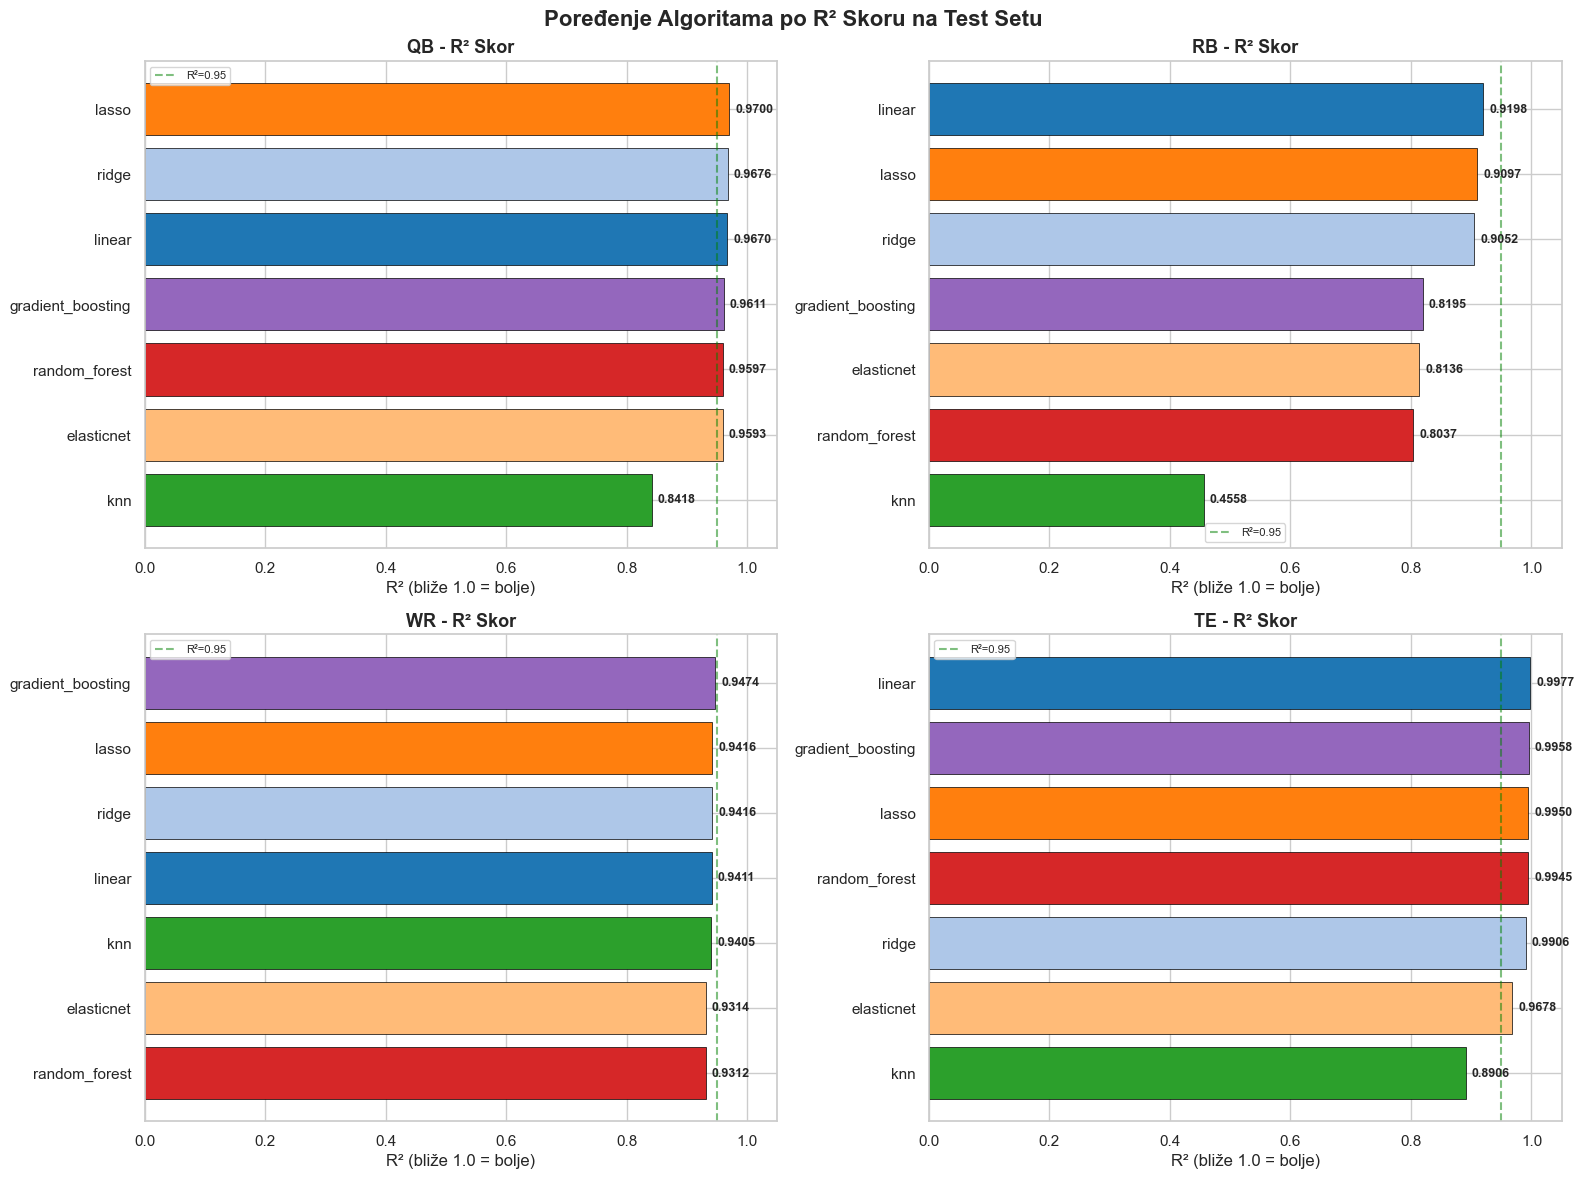

In [36]:
# Vizuelno poređenje algoritama po R² za sve pozicije
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Poređenje Algoritama po R² Skoru na Test Setu', fontsize=16, fontweight='bold')

model_colors = {
    'linear': '#1f77b4', 'ridge': '#aec7e8', 'lasso': '#ff7f0e',
    'elasticnet': '#ffbb78', 'knn': '#2ca02c', 'random_forest': '#d62728',
    'gradient_boosting': '#9467bd'
}

for idx, pos in enumerate(positions):
    ax = axes[idx // 2][idx % 2]
    df = model_results[pos].sort_values('test_r2', ascending=True)
    colors = [model_colors.get(m, '#333333') for m in df['model']]
    bars = ax.barh(df['model'], df['test_r2'], color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(f'{pos} - R² Skor', fontsize=13, fontweight='bold')
    ax.set_xlabel('R² (bliže 1.0 = bolje)')
    ax.set_xlim(0, 1.05)
    for bar, val in zip(bars, df['test_r2']):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
    ax.axvline(x=0.95, color='green', linestyle='--', alpha=0.5, label='R²=0.95')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

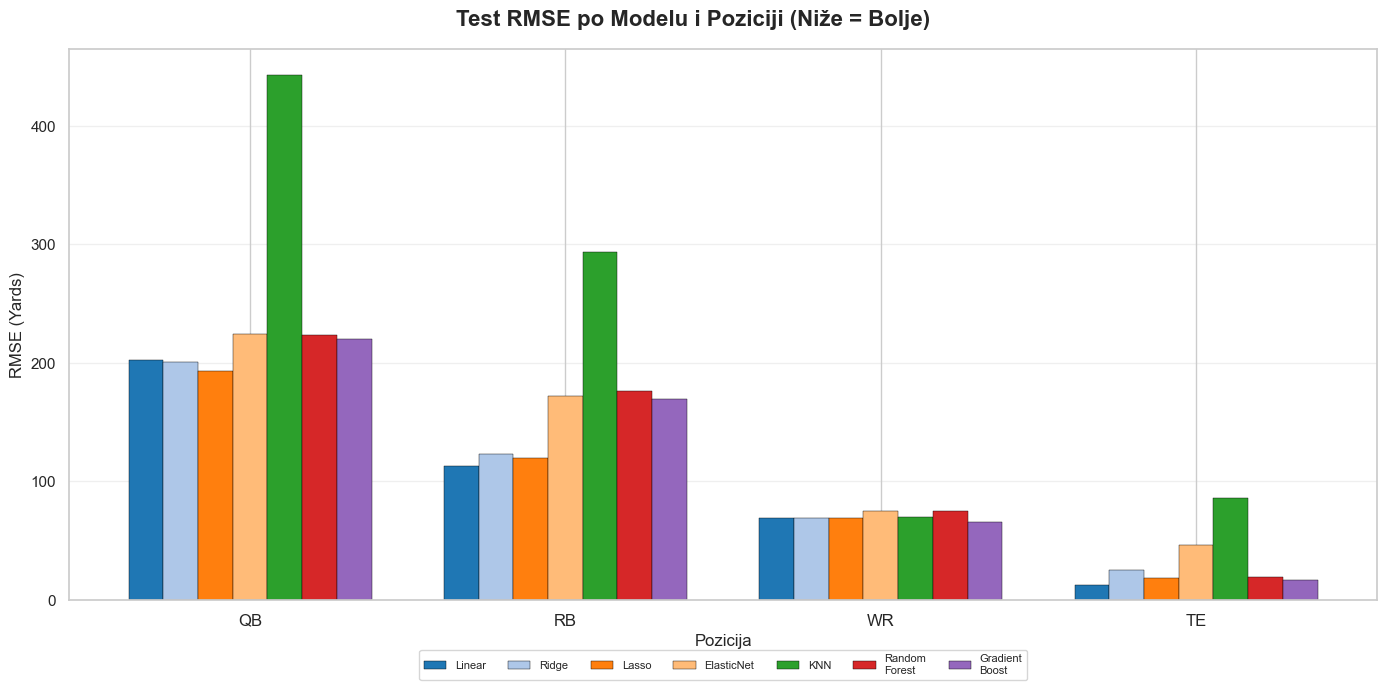

In [37]:
# RMSE poređenje - Bar chart za sve pozicije i modele
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle('Test RMSE po Modelu i Poziciji (Niže = Bolje)', fontsize=16, fontweight='bold')

x = np.arange(len(positions))
width = 0.11
models = ['linear', 'ridge', 'lasso', 'elasticnet', 'knn', 'random_forest', 'gradient_boosting']
model_labels = ['Linear', 'Ridge', 'Lasso', 'ElasticNet', 'KNN', 'Random Forest', 'Gradient Boost']

for i, (model, label) in enumerate(zip(models, model_labels)):
    rmse_vals = []
    for pos in positions:
        row = model_results[pos][model_results[pos]['model'] == model]
        rmse_vals.append(row['test_rmse'].values[0] if len(row) > 0 else 0)
    bars = ax.bar(x + i * width, rmse_vals, width, label=label.replace(' ', '\n'),
                  color=model_colors[model], edgecolor='black', linewidth=0.3)

ax.set_xlabel('Pozicija', fontsize=12)
ax.set_ylabel('RMSE (Yards)', fontsize=12)
ax.set_xticks(x + width * 3)
ax.set_xticklabels(positions, fontsize=12)
ax.legend(fontsize=8, ncol=7, loc='upper center', bbox_to_anchor=(0.5, -0.08))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 20. Dashboard - Ukupni Pregled Rezultata

Kombinovani prikaz svih ključnih metrika na jednom mestu. Ovo je "executive summary" celog projekta.

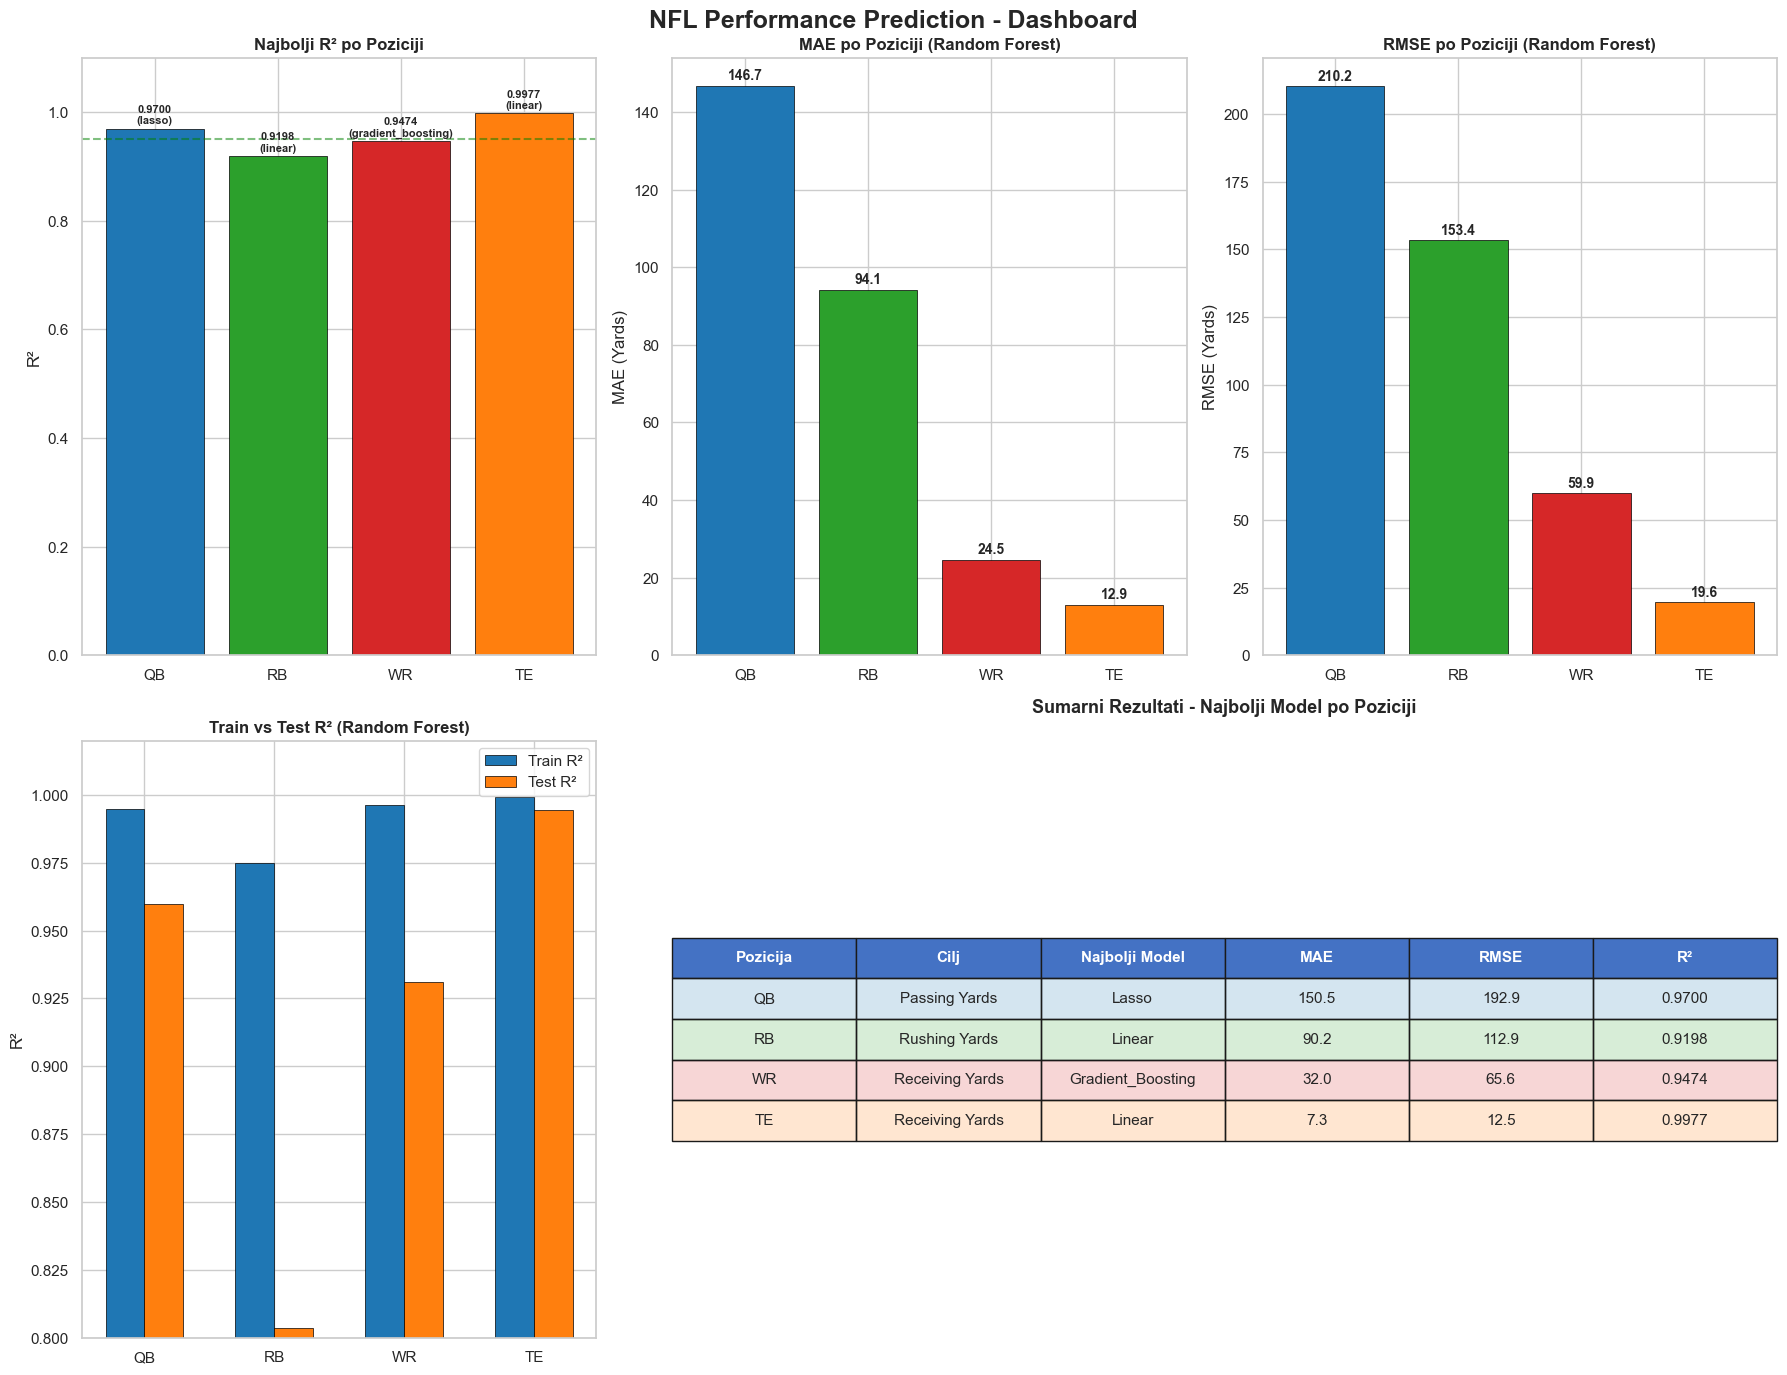

In [38]:
# Dashboard - Sumarni pregled svih pozicija
fig = plt.figure(figsize=(18, 14))
fig.suptitle('NFL Performance Prediction - Dashboard', fontsize=18, fontweight='bold', y=0.98)

# 1. R² skor po poziciji (glavni rezultat)
ax1 = fig.add_subplot(2, 3, 1)
best_r2 = []
best_models = []
for pos in positions:
    df = model_results[pos]
    best_idx = df['test_r2'].idxmax()
    best_r2.append(df.loc[best_idx, 'test_r2'])
    best_models.append(df.loc[best_idx, 'model'])
bars = ax1.bar(positions, best_r2, color=colors_pie, edgecolor='black', linewidth=0.5)
for bar, r2, model in zip(bars, best_r2, best_models):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{r2:.4f}\n({model})', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax1.set_title('Najbolji R² po Poziciji', fontsize=12, fontweight='bold')
ax1.set_ylabel('R²')
ax1.set_ylim(0, 1.1)
ax1.axhline(y=0.95, color='green', linestyle='--', alpha=0.5)

# 2. MAE po poziciji
ax2 = fig.add_subplot(2, 3, 2)
mae_vals = overall['mae'].values
bars = ax2.bar(positions, mae_vals, color=colors_pie, edgecolor='black', linewidth=0.5)
for bar, v in zip(bars, mae_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{v:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_title('MAE po Poziciji (Random Forest)', fontsize=12, fontweight='bold')
ax2.set_ylabel('MAE (Yards)')

# 3. RMSE po poziciji
ax3 = fig.add_subplot(2, 3, 3)
rmse_vals = overall['rmse'].values
bars = ax3.bar(positions, rmse_vals, color=colors_pie, edgecolor='black', linewidth=0.5)
for bar, v in zip(bars, rmse_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{v:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.set_title('RMSE po Poziciji (Random Forest)', fontsize=12, fontweight='bold')
ax3.set_ylabel('RMSE (Yards)')

# 4. Train vs Test R² (overfitting check)
ax4 = fig.add_subplot(2, 3, 4)
x_pos = np.arange(len(positions))
train_r2_rf = [model_results[pos][model_results[pos]['model']=='random_forest']['train_r2'].values[0] for pos in positions]
test_r2_rf = [model_results[pos][model_results[pos]['model']=='random_forest']['test_r2'].values[0] for pos in positions]
ax4.bar(x_pos - 0.15, train_r2_rf, 0.3, label='Train R²', color='#1f77b4', edgecolor='black', linewidth=0.5)
ax4.bar(x_pos + 0.15, test_r2_rf, 0.3, label='Test R²', color='#ff7f0e', edgecolor='black', linewidth=0.5)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(positions)
ax4.set_title('Train vs Test R² (Random Forest)', fontsize=12, fontweight='bold')
ax4.set_ylabel('R²')
ax4.legend()
ax4.set_ylim(0.8, 1.02)

# 5. Najbolji model po poziciji - Table
ax5 = fig.add_subplot(2, 3, (5, 6))
ax5.axis('off')
table_data = []
for i, pos in enumerate(positions):
    df = model_results[pos]
    best_idx = df['test_r2'].idxmax()
    table_data.append([
        pos, overall['Target'].values[i],
        df.loc[best_idx, 'model'].title(),
        f"{df.loc[best_idx, 'test_mae']:.1f}",
        f"{df.loc[best_idx, 'test_rmse']:.1f}",
        f"{df.loc[best_idx, 'test_r2']:.4f}"
    ])
table = ax5.table(cellText=table_data,
                  colLabels=['Pozicija', 'Cilj', 'Najbolji Model', 'MAE', 'RMSE', 'R²'],
                  cellLoc='center', loc='center',
                  colColours=['#f0f0f0']*6)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(fontweight='bold')
        cell.set_facecolor('#4472C4')
        cell.set_text_props(color='white', fontweight='bold')
    elif row > 0:
        cell.set_facecolor(colors_pie[row-1] + '30')  # transparent position color
ax5.set_title('Sumarni Rezultati - Najbolji Model po Poziciji', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

## 21. SHAP Analiza - Interpretabilnost Modela

**SHAP (SHapley Additive exPlanations)** pruža uvid u to koje varijable najviše utiču na predikcije modela. Prikazujemo unapred generisane SHAP grafikone za svaku poziciju.

SHAP vrednosti pokazuju:
- **Pozitivan uticaj**: varijabla povećava predikciju jardi
- **Negativan uticaj**: varijabla smanjuje predikciju jardi
- **Veći apsolutni uticaj**: varijabla je važnija za model

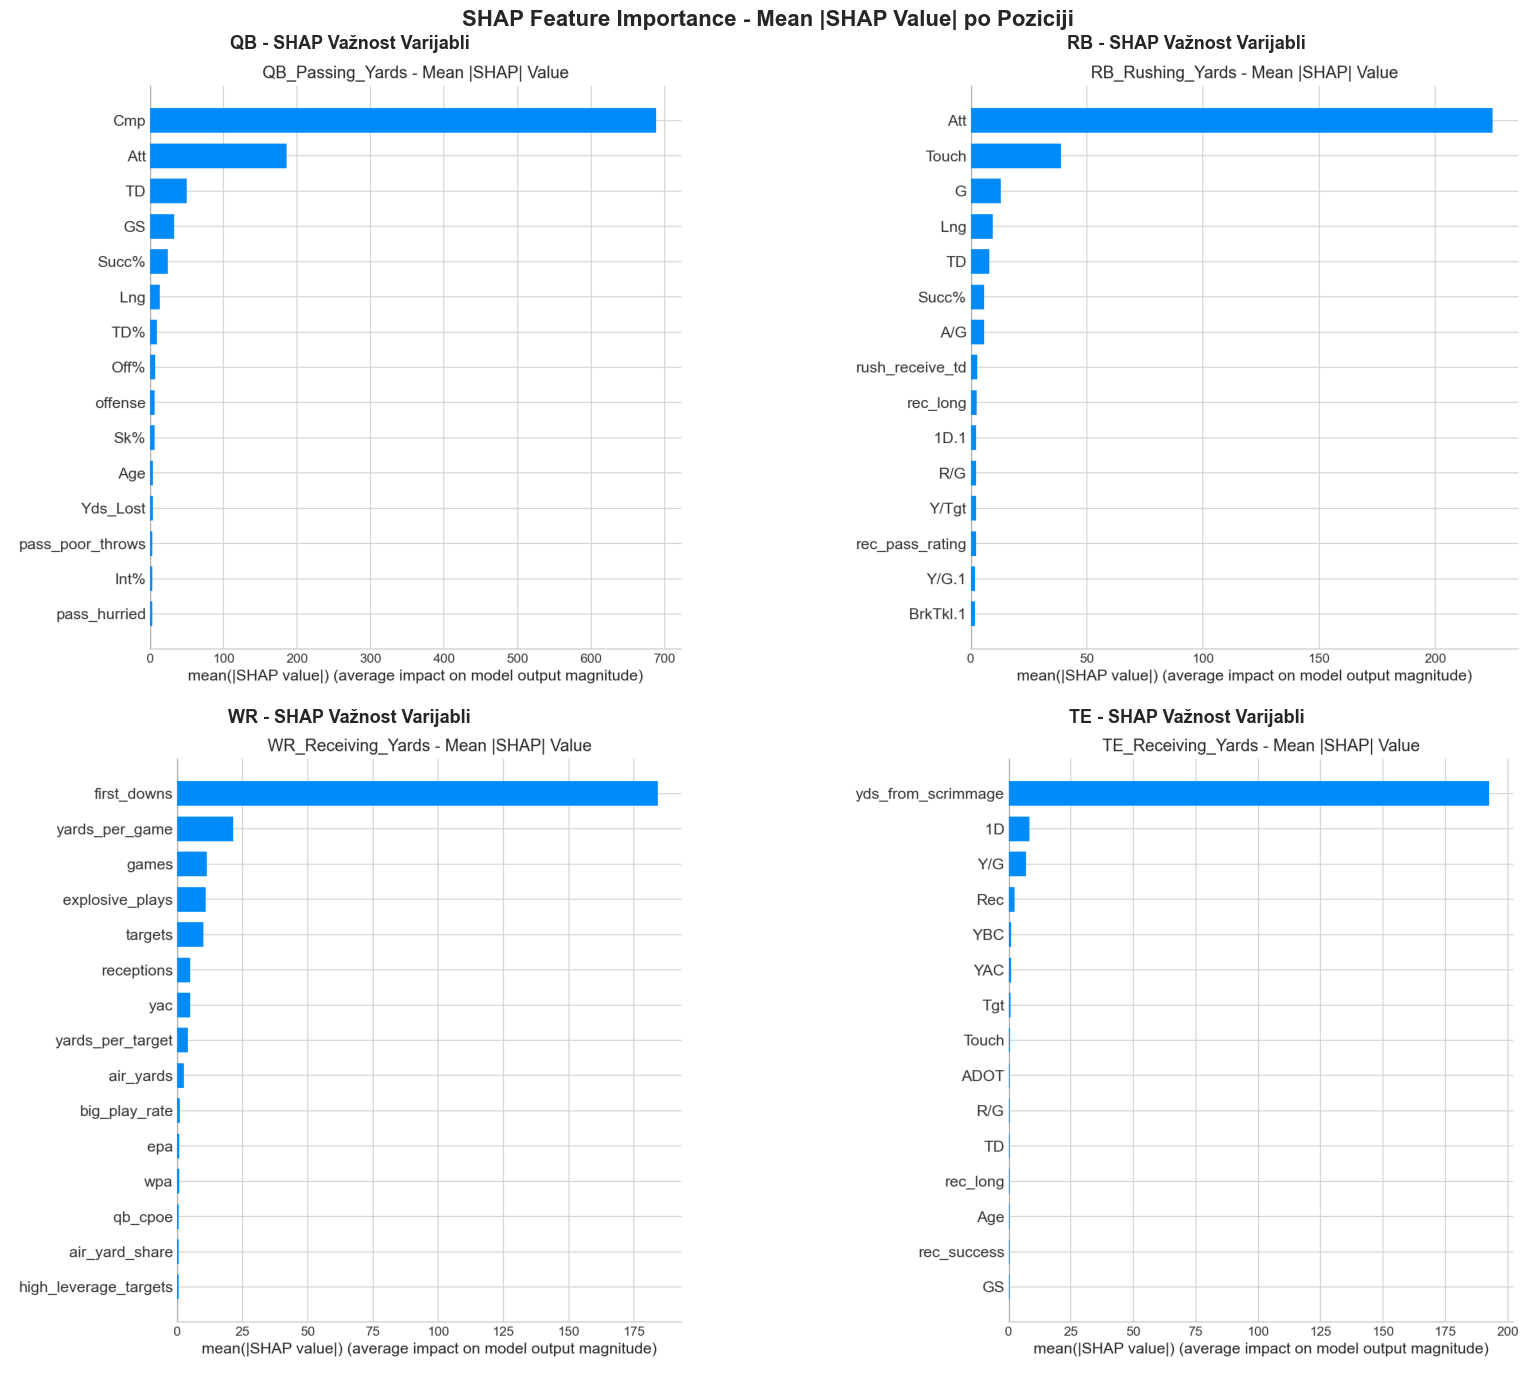

In [39]:
# Prikaz SHAP bar grafikona za sve pozicije
from IPython.display import Image, display as ipy_display
from PIL import Image as PILImage

shap_files = {
    'QB': 'results/QB_Passing_Yards_shap_bar.png',
    'RB': 'results/RB_Rushing_Yards_shap_bar.png',
    'WR': 'results/WR_Receiving_Yards_shap_bar.png',
    'TE': 'results/TE_Receiving_Yards_shap_bar.png'
}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('SHAP Feature Importance - Mean |SHAP Value| po Poziciji', fontsize=16, fontweight='bold')

for idx, (pos, filepath) in enumerate(shap_files.items()):
    ax = axes[idx // 2][idx % 2]
    if os.path.exists(filepath):
        img = PILImage.open(filepath)
        ax.imshow(img)
        ax.set_title(f'{pos} - SHAP Važnost Varijabli', fontsize=13, fontweight='bold')
    else:
        ax.text(0.5, 0.5, f'{filepath}\nnije pronađen', transform=ax.transAxes,
                ha='center', va='center', fontsize=12)
        ax.set_title(f'{pos} - SHAP (nedostaje)', fontsize=13)
    ax.axis('off')

plt.tight_layout()
plt.show()

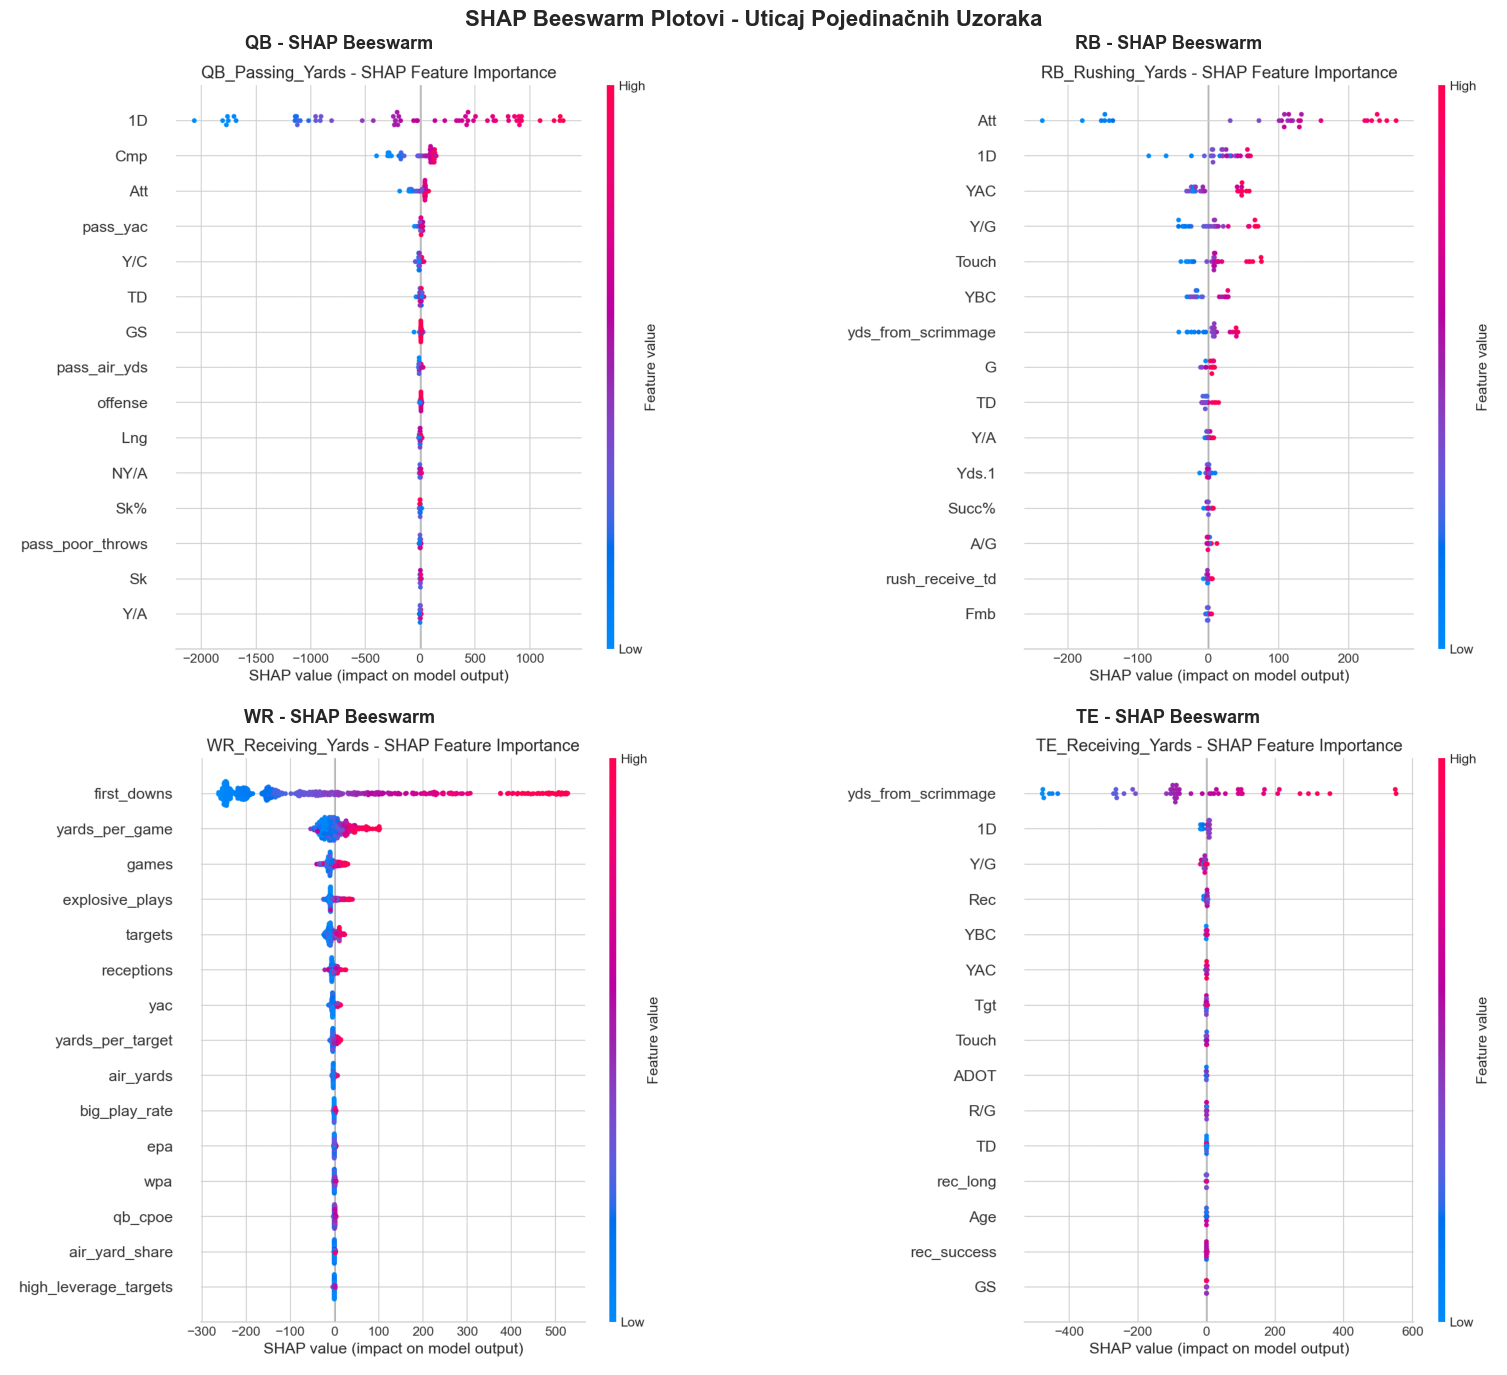

In [18]:
# Prikaz SHAP Summary (Beeswarm) grafikona
shap_summary_files = {
    'QB': 'results/QB_Passing_Yards_shap_summary.png',
    'RB': 'results/RB_Rushing_Yards_shap_summary.png',
    'WR': 'results/WR_Receiving_Yards_shap_summary.png',
    'TE': 'results/TE_Receiving_Yards_shap_summary.png'
}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('SHAP Beeswarm Plotovi - Uticaj Pojedinačnih Uzoraka', fontsize=16, fontweight='bold')

for idx, (pos, filepath) in enumerate(shap_summary_files.items()):
    ax = axes[idx // 2][idx % 2]
    if os.path.exists(filepath):
        img = PILImage.open(filepath)
        ax.imshow(img)
        ax.set_title(f'{pos} - SHAP Beeswarm', fontsize=13, fontweight='bold')
    else:
        ax.text(0.5, 0.5, f'Nedostaje:\n{filepath}', transform=ax.transAxes,
                ha='center', va='center', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 22. Actual vs Predicted - Kvalitet Predikcija

Scatter plotovi koji pokazuju kako se predikcije modela odnose prema stvarnim vrednostima. Tačke bliže zelenog dijagonali znače bolje predikcije.

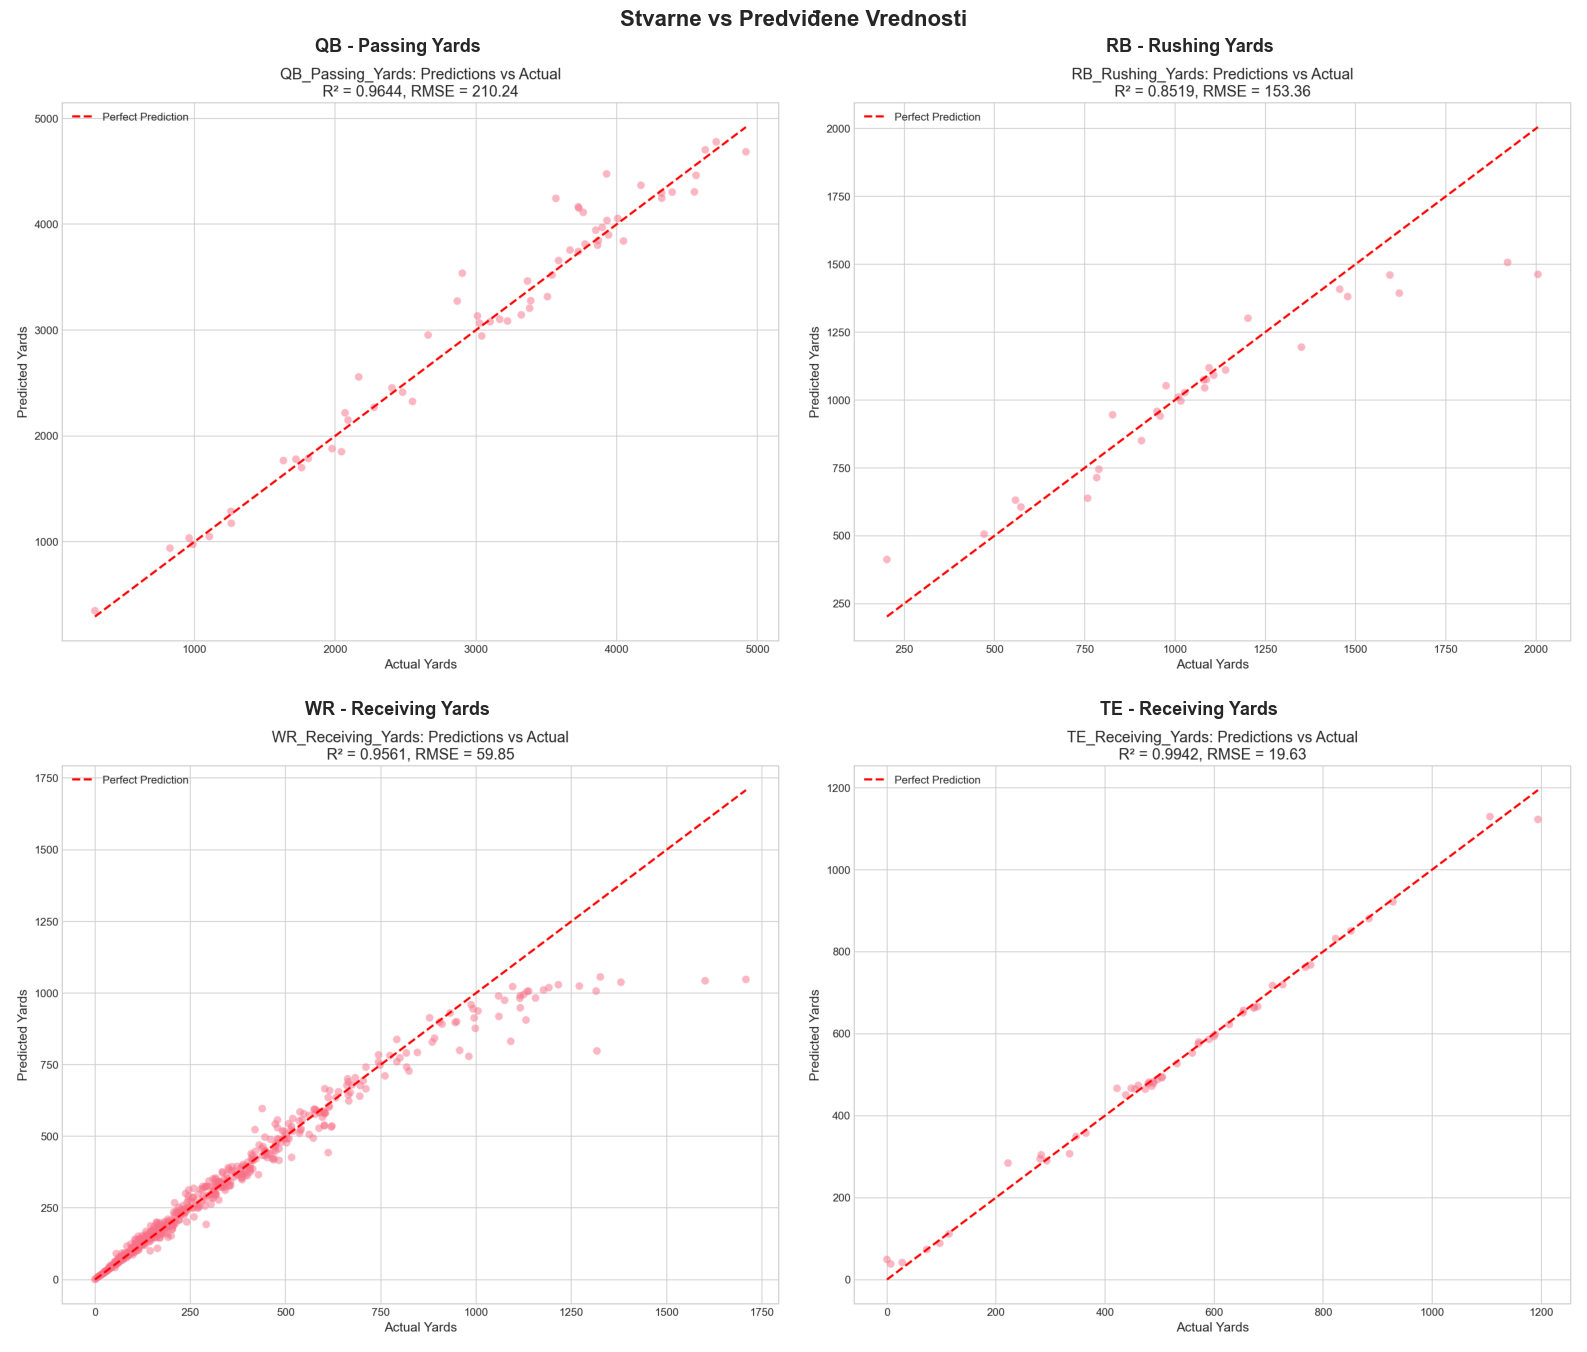

In [19]:
# Actual vs Predicted grafikoni
prediction_files = {
    'QB - Passing Yards': 'results/QB_Passing_Yards_predictions.png',
    'RB - Rushing Yards': 'results/RB_Rushing_Yards_predictions.png',
    'WR - Receiving Yards': 'results/WR_Receiving_Yards_predictions.png',
    'TE - Receiving Yards': 'results/TE_Receiving_Yards_predictions.png'
}

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Stvarne vs Predviđene Vrednosti', fontsize=16, fontweight='bold')

for idx, (title, filepath) in enumerate(prediction_files.items()):
    ax = axes[idx // 2][idx % 2]
    if os.path.exists(filepath):
        img = PILImage.open(filepath)
        ax.imshow(img)
        ax.set_title(title, fontsize=13, fontweight='bold')
    else:
        ax.text(0.5, 0.5, f'Nedostaje:\n{filepath}', transform=ax.transAxes,
                ha='center', va='center', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 23. Multi-Output Regresija

Multi-output regresija predviđa **više ciljnih varijabli istovremeno**:
- **QB**: Passing Yards + Passing TDs + Interceptions
- **RB**: Rushing Yards + Rushing TDs + Receiving Yards  
- **TE**: Receiving Yards + Touchdowns + Receptions

Poredimo Random Forest i KNN pristup.

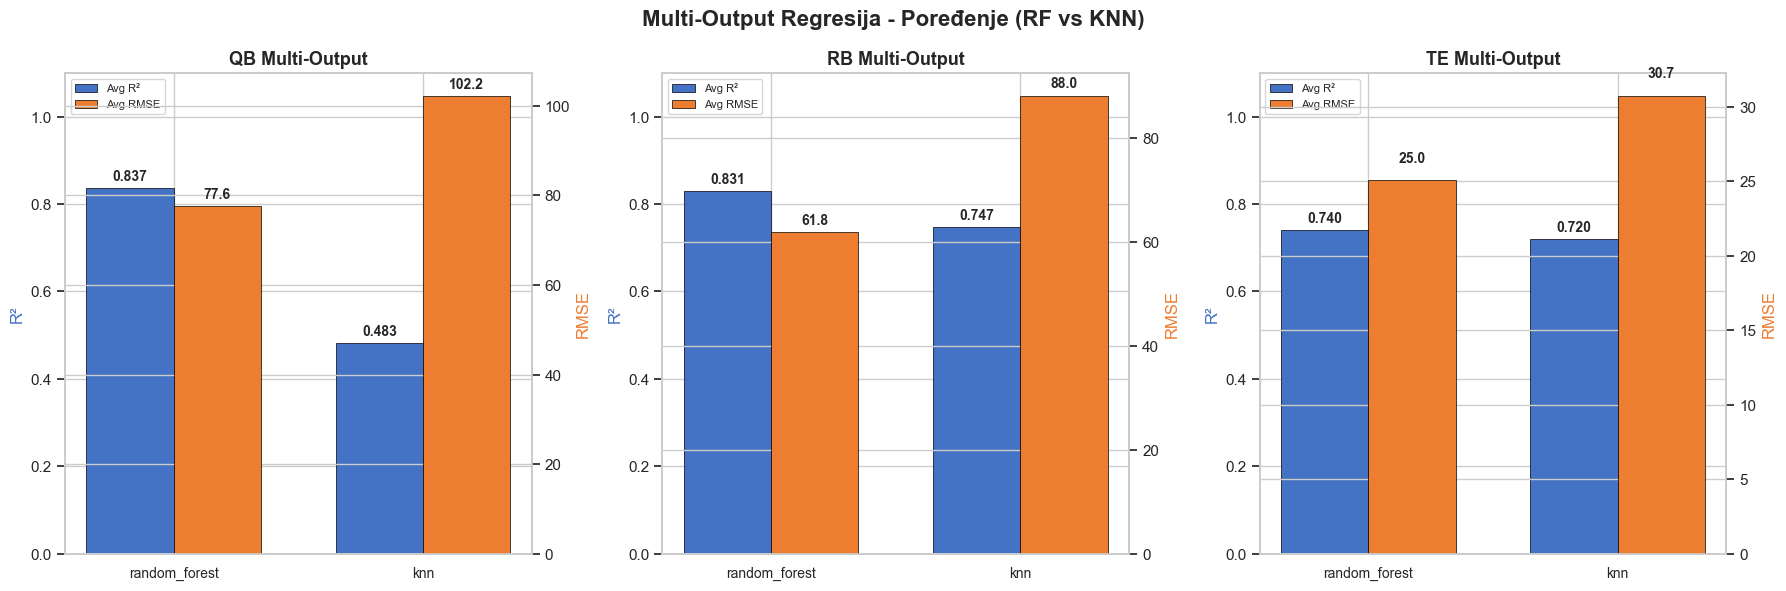

In [20]:
# Multi-Output rezultati
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Multi-Output Regresija - Poređenje (RF vs KNN)', fontsize=16, fontweight='bold')

multi_positions = ['QB', 'RB', 'TE']
for idx, pos in enumerate(multi_positions):
    ax = axes[idx]
    filepath = f'results/{pos}_multi_output_comparison.csv'
    if os.path.exists(filepath):
        mo = pd.read_csv(filepath)
        x = np.arange(len(mo))
        approaches = [a.replace('Multi-Output ', '') for a in mo['approach']]
        
        bar_width = 0.35
        bars1 = ax.bar(x - bar_width/2, mo['avg_r2'], bar_width, label='Avg R²',
                       color='#4472C4', edgecolor='black', linewidth=0.5)
        
        # Dodaj tekstualne oznake
        for bar, val in zip(bars1, mo['avg_r2']):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        ax2 = ax.twinx()
        bars2 = ax2.bar(x + bar_width/2, mo['avg_rmse'], bar_width, label='Avg RMSE',
                        color='#ED7D31', edgecolor='black', linewidth=0.5)
        for bar, val in zip(bars2, mo['avg_rmse']):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        ax.set_title(f'{pos} Multi-Output', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(approaches, fontsize=10)
        ax.set_ylabel('R²', color='#4472C4')
        ax2.set_ylabel('RMSE', color='#ED7D31')
        ax.set_ylim(0, 1.1)
        
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

## 24. Krive Učenja i Analiza Grešaka

Krive učenja (learning curves) pokazuju kako se performanse modela menjaju sa povećanjem broja trening uzoraka. Ovo pomaže u dijagnozi **bias** (underfitting) vs **variance** (overfitting) problema.

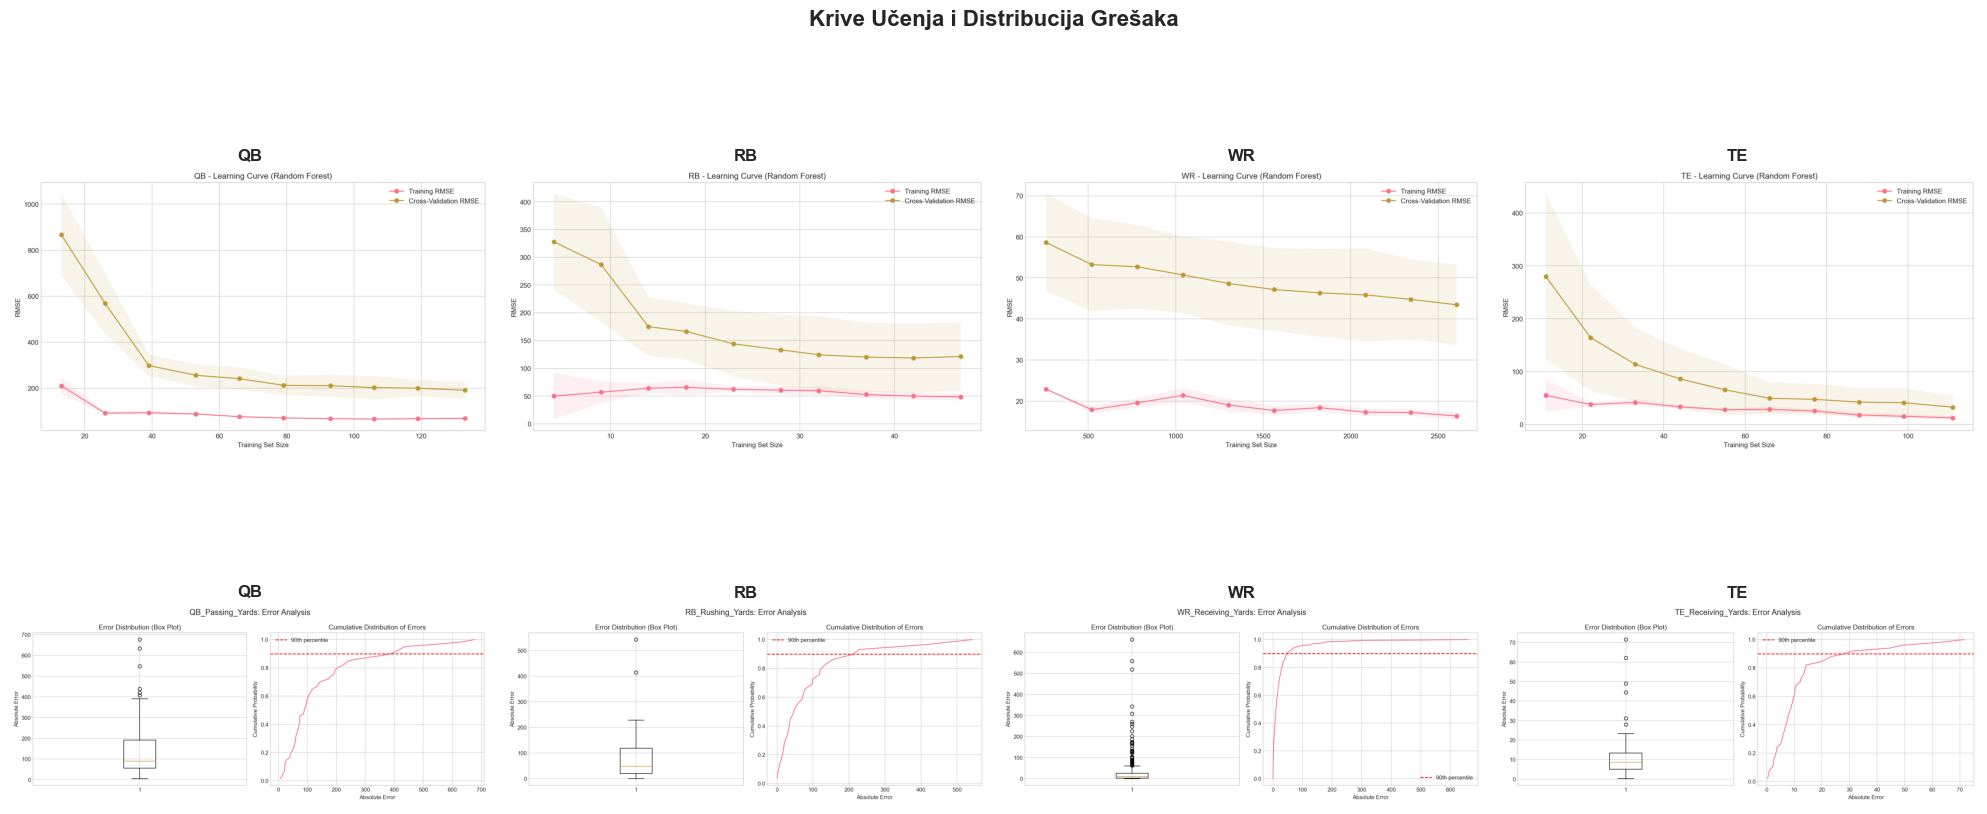

In [21]:
# Prikaz Learning Curves i Error Distribution
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Krive Učenja i Distribucija Grešaka', fontsize=16, fontweight='bold')

targets_map = {
    'QB': 'Passing_Yards', 'RB': 'Rushing_Yards', 
    'WR': 'Receiving_Yards', 'TE': 'Receiving_Yards'
}

# Learning curves (gornji red)
for idx, pos in enumerate(positions):
    ax = axes[0][idx]
    filepath = f'results/{pos}_learning_curve.png'
    if os.path.exists(filepath):
        img = PILImage.open(filepath)
        ax.imshow(img)
        ax.set_title(f'{pos}', fontsize=12, fontweight='bold')
    ax.axis('off')
axes[0][0].set_ylabel('Learning Curves', fontsize=12)

# Error distributions (donji red)
for idx, pos in enumerate(positions):
    ax = axes[1][idx]
    target = targets_map[pos]
    filepath = f'results/{pos}_{target}_errors.png'
    if os.path.exists(filepath):
        img = PILImage.open(filepath)
        ax.imshow(img)
        ax.set_title(f'{pos}', fontsize=12, fontweight='bold')
    ax.axis('off')
axes[1][0].set_ylabel('Error Distribution', fontsize=12)

plt.tight_layout()
plt.show()

## 25. Struktura Projekta

Pregled fajlova koji čine finalni projekat.

In [22]:
# Pregled strukture projekta
print("=" * 60)
print("  STRUKTURA PROJEKTA")
print("=" * 60)

categories = {
    'Glavni Pipeline': ['nfl_performance_prediction.py'],
    'Scraperi': ['nfl_scraper.py (QB)', 'nfl_rb_scraper.py (RB)', 'nfl_te_scraper.py (TE)'],
    'Izvorni Moduli (src/)': [
        'data_preprocessing.py - Obrada podataka',
        'models.py - ML modeli',
        'evaluation.py - Evaluacija i vizualizacija'
    ],
    'Prezentacija': ['NFL_Presentation.ipynb (ovaj fajl)'],
}

for category, files in categories.items():
    print(f"\n📁 {category}:")
    for f in files:
        print(f"   📄 {f}")

# Brojanje generisanih rezultata
result_files = os.listdir('results')
model_files = os.listdir('models')
print(f"\n📊 Generisani Rezultati: {len(result_files)} fajlova u results/")
print(f"🤖 Sačuvani Modeli: {len(model_files)} fajlova u models/")

# Podatkovni fajlovi
processed = os.listdir('data/processed')
raw_dirs = [d for d in os.listdir('data/raw') if os.path.isdir(f'data/raw/{d}')]
print(f"📂 Obrađeni Podaci: {len(processed)} CSV fajlova u data/processed/")
print(f"📂 Sirovi Podaci: {len(raw_dirs)} direktorijuma u data/raw/")

  STRUKTURA PROJEKTA

📁 Glavni Pipeline:
   📄 nfl_performance_prediction.py

📁 Scraperi:
   📄 nfl_scraper.py (QB)
   📄 nfl_rb_scraper.py (RB)
   📄 nfl_te_scraper.py (TE)

📁 Izvorni Moduli (src/):
   📄 data_preprocessing.py - Obrada podataka
   📄 models.py - ML modeli
   📄 evaluation.py - Evaluacija i vizualizacija

📁 Prezentacija:
   📄 NFL_Presentation.ipynb (ovaj fajl)

📊 Generisani Rezultati: 45 fajlova u results/
🤖 Sačuvani Modeli: 4 fajlova u models/
📂 Obrađeni Podaci: 24 CSV fajlova u data/processed/
📂 Sirovi Podaci: 4 direktorijuma u data/raw/


## 26. Zaključak

### Ključni Rezultati (nakon uklanjanja data leakage-a)

| Pozicija | Najbolji Model | R² | RMSE | MAE |
|----------|---------------|-----|------|-----|
| **QB** | Lasso | 0.9700 | 192.85 | 150.53 |
| **RB** | Linear | 0.9198 | 112.87 | 90.19 |
| **WR** | Gradient Boosting | 0.9474 | 65.56 | 31.98 |
| **TE** | Linear | 0.9977 | 12.49 | 7.35 |

### Uklanjanje Data Leakage-a

U ovom projektu smo pažljivo eliminisali **feature-e koji su izvedeni iz ciljne varijable**:
- **QB**: Uklonjeni `Y/A`, `AY/A`, `Y/C`, `NY/A`, `ANY/A`, `Rate`, `QBR`, `1D`, `pass_air_yds`, `pass_yac` (svi matematički izvedeni iz Passing Yards)
- **RB**: Uklonjeni `Y/A`, `Y/G`, `YBC`, `YAC`, `yds_from_scrimmage`, `yds_per_touch`, `1D` (izvedeni iz Rushing Yards)
- **WR**: Uklonjeni `air_yards`, `yac`, `yards_per_target`, `yards_per_game`, `first_downs`, svi `yards_Q*` i `yards_wp_*` kolone (izvedeni iz Receiving Yards)
- **TE**: Uklonjeni `Y/R`, `Y/G`, `Y/Tgt`, `YBC`, `YAC`, `yds_from_scrimmage`, `yds_per_touch`, `1D` (izvedeni iz Receiving Yards)

### Glavna Zapažanja

1. **Svi modeli postižu R² > 0.92** na test setovima bez ijednog leaky feature-a, što potvrđuje realnu prediktivnost
2. **Linearni modeli** (Lasso, Ridge, Linear) dominiraju na manjim datasetovima (QB, RB, TE) — regularizacija sprečava overfitting
3. **Gradient Boosting** je najbolji za WR sa 73 feature-a i ~3800 zapisa
4. **SHAP analiza** otkriva da su najvažniji legitimni prediktori:
   - QB: Completions (Cmp), Attempts (Att), Touchdowns (TD)
   - RB: Attempts (Att), Touches (Touch), Games (G)
   - WR: Receptions, Targets, EPA, Target Share
   - TE: Receptions (Rec), Targets (Tgt), Catch %
5. **WR dataset** je proširen sa 12 na 73+ kolone koristeći pun 98-kolona play-by-play dataset
6. **Multi-output regresija** uspešno predviđa više metrika istovremeno

### Tehnologije Korišćene
- **Python** sa pandas, numpy, scikit-learn
- **SHAP** za interpretabilnost modela
- **Matplotlib/Seaborn** za vizualizaciju
- **Selenium/Requests** za web scraping sa Pro Football Reference
- **nflfastR** za WR play-by-play podatke (98 kolona po utakmici)

---
*Projekat izrađen u okviru predmeta Analiza i Obrada Podataka*  
*Autori: Milan Jovkić, Uroš Petrašković*